<a href="https://colab.research.google.com/github/D2718281828nis/BioMedAI/blob/main/ML_table_EDA_heart_decease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Title: ЗАДАЧА

По данным о пациенте из заданного датасета научиться предсказывать наличие у него сердечно-сосудистого заболевания



# 1. ПРЕДОБРАБОТКА ДАННЫХ

Это задача **бинарной классификации**.
Необходимо построить разделяющую поверхность в пространстве признаков, разделяющую пространство на 2 части, каждая из которых соответствует определённому классу: есть заболевание или нет заболевания.

## ИМПОРТ ДАННЫХ

* Загрузим необходимые библиотеки

In [99]:
import pandas as pd                  # Импорт библиотеки pandas для работы с табличными данными (DataFrame)
import numpy as np                   # Импорт библиотеки numpy для работы с массивами и числовыми операциями
import seaborn as sns                # Импорт библиотеки seaborn для создания красивых и информативных визуализаций данных
from matplotlib import pyplot as plt # Импорт функции pyplot из библиотеки matplotlib для создания графиков и визуализаций

from sklearn.preprocessing import OneHotEncoder, StandardScaler # Импорт классов для кодирования категориальных признаков и стандартизации данных

* Загрузим набор данных

**.tsv** означает, что разделителем в таблице является знак табуляции. Чтобы таблица загрузилась в классическом виде, необходимо в функции **read_csv()** библиотеки **pandas** указать аргумент **sep='\t'**

In [100]:
heart = pd.read_csv('/content/dataset_heart_risk.tsv', sep='\t')
heart.head().T # выведем первые 5 строк таблицы

,0,1,2,3,4
ID,0,1,2,3,4
Бронхиальная астма,0,0,0,0,0
ЛПНП,2.79,6.62,3.17,2.74,6.62
Возраст алког,18.0,NaN,17.0,13.0,16.0
Работа,1,0,0,1,0
ВИЧ/СПИД,0,0,0,0,0
Статус Курения,Курит,Никогда не курил(а),Никогда не курил(а),Бросил(а),Никогда не курил(а)
Пассивное курение,0,0,1,1,1
Переломы,0,1,0,0,1
Время пробуждения,06:00:00,04:00:00,07:00:00,07:00:00,06:00:00


In [101]:
display(heart.tail())

,ID,Бронхиальная астма,ЛПНП,Возраст алког,Работа,ВИЧ/СПИД,Статус Курения,Пассивное курение,Переломы,Время пробуждения,...,Сон после обеда,Время засыпания,Хроническое заболевание легких,Сигарет в день,Образование,"Индекс массы тела, кг/м^2",Прекращение работы по болезни,Религия,Профессия,ССЗ
951,951,0,2.80,26.0,1,0,Курит,0,0,07:15:00,...,0,21:30:00,0,10.0,3 - средняя школа / закон.среднее / выше среднего,26.0,0,Христианство,низкоквалифицированные работники,0
952,952,0,3.28,20.0,0,0,Бросил(а),0,0,08:00:00,...,1,22:30:00,0,10.0,3 - средняя школа / закон.среднее / выше среднего,27.8,0,Христианство,служащие,1
953,953,0,2.57,21.0,1,0,Никогда не курил(а),0,0,08:30:00,...,0,23:00:00,0,NaN,5 - ВУЗ,23.1,0,Атеист / агностик,"представители законодат. органов власти,...",0
954,954,0,3.53,17.0,1,0,Курит,0,1,05:00:00,...,1,22:00:00,0,30.0,4 - профессиональное училище,27.6,0,Христианство,операторы и монтажники установок и машинного о...,1
955,956,0,3.81,NaN,0,0,Никогда не курил(а),1,1,05:00:00,...,0,23:00:00,0,NaN,3 - средняя школа / закон.среднее / выше среднего,34.0,0,Ислам,ведение домашнего хозяйства,1


## ПРОВЕРКА ДАННЫХ

* Узнаем количество строк и столбцов в датафрейме

In [102]:
heart.shape

(956, 42)

956 строк и 42 столбца

* Посмотрим информацию о признаках

In [103]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 42 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   ID                                      956 non-null    int64  
 1   Бронхиальная астма                      956 non-null    int64  
 2   ЛПНП                                    956 non-null    float64
 3   Возраст алког                           788 non-null    float64
 4   Работа                                  956 non-null    int64  
 5   ВИЧ/СПИД                                956 non-null    int64  
 6   Статус Курения                          956 non-null    object 
 7   Пассивное курение                       956 non-null    int64  
 8   Переломы                                956 non-null    int64  
 9   Время пробуждения                       956 non-null    object 
 10  ЛПВП                                    956 non-null    float6

* Выведем названия всех признаков в наборе данных **heart**

In [104]:
heart.columns

Index(['ID', 'Бронхиальная астма', 'ЛПНП', 'Возраст алког', 'Работа',
       'ВИЧ/СПИД', 'Статус Курения', 'Пассивное курение', 'Переломы',
       'Время пробуждения', 'ЛПВП', 'Выход на пенсию', 'Холестерин',
       'Артериальная гипертония', 'Триглицериды', 'Гепатит', 'Сахарный диабет',
       'Пол', 'Спорт, клубы', 'Семья', 'Религия, клубы', 'Частота пасс кур',
       'Возраст курения', 'Туберкулез легких', 'Онкология', 'Травмы за год',
       'Регулярный прием лекарственных средств', 'Этнос', 'Национальность',
       'Алкоголь', 'Глюкоза плазмы натощак', 'Абдоминальное ожирение, см',
       'Сон после обеда', 'Время засыпания', 'Хроническое заболевание легких',
       'Сигарет в день', 'Образование', 'Индекс массы тела, кг/м^2',
       'Прекращение работы по болезни', 'Религия', 'Профессия', 'ССЗ'],
      dtype='object')

* Посмотрим опимсательную статистику числовых признаков с помощью метода  **.describe()**, округлив значения до 2-х знаков после запятой c помощью **round()**

In [105]:
heart.describe().round(2)

,ID,Бронхиальная астма,ЛПНП,Возраст алког,Работа,ВИЧ/СПИД,Пассивное курение,Переломы,ЛПВП,Выход на пенсию,...,Травмы за год,Регулярный прием лекарственных средств,Глюкоза плазмы натощак,"Абдоминальное ожирение, см",Сон после обеда,Хроническое заболевание легких,Сигарет в день,"Индекс массы тела, кг/м^2",Прекращение работы по болезни,ССЗ
count,956.00,956.00,956.00,788.00,956.00,956.00,956.00,956.00,956.00,956.00,...,956.00,956.00,956.00,956.00,956.00,956.00,409.00,956.00,956.00,956.00
mean,477.50,0.04,3.87,20.04,0.52,0.00,0.24,0.35,1.07,0.33,...,0.05,0.64,6.67,80.20,0.23,0.08,14.22,28.19,0.05,0.55
std,276.12,0.20,1.57,5.18,0.50,0.05,0.42,0.48,0.37,0.47,...,0.22,0.48,2.86,12.25,0.42,0.26,10.15,4.82,0.21,0.50
min,0.00,0.00,0.08,6.00,0.00,0.00,0.00,0.00,-0.68,0.00,...,0.00,0.00,1.85,59.10,0.00,0.00,1.00,18.00,0.00,0.00
25%,238.75,0.00,2.64,17.00,0.00,0.00,0.00,0.00,0.85,0.00,...,0.00,0.00,4.75,68.30,0.00,0.00,6.00,24.20,0.00,0.00
50%,477.50,0.00,3.33,19.00,1.00,0.00,0.00,0.00,1.11,0.00,...,0.00,1.00,6.00,81.40,0.00,0.00,10.00,27.60,0.00,1.00
75%,716.25,0.00,5.06,20.00,1.00,0.00,0.00,1.00,1.34,1.00,...,0.00,1.00,7.89,90.40,0.00,0.00,20.00,32.30,0.00,1.00
max,956.00,1.00,7.91,63.00,1.00,1.00,1.00,1.00,1.79,1.00,...,1.00,1.00,25.83,110.70,1.00,1.00,60.00,37.00,1.00,1.00


* Для удобства изучения транспонируем таблицу

In [106]:
heart.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
ID,956.0,477.50,276.12,0.00,238.75,477.50,716.25,956.00
Бронхиальная астма,956.0,0.04,0.20,0.00,0.00,0.00,0.00,1.00
ЛПНП,956.0,3.87,1.57,0.08,2.64,3.33,5.06,7.91
Возраст алког,788.0,20.04,5.18,6.00,17.00,19.00,20.00,63.00
Работа,956.0,0.52,0.50,0.00,0.00,1.00,1.00,1.00
ВИЧ/СПИД,956.0,0.00,0.05,0.00,0.00,0.00,0.00,1.00
Пассивное курение,956.0,0.24,0.42,0.00,0.00,0.00,0.00,1.00
Переломы,956.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00
ЛПВП,956.0,1.07,0.37,-0.68,0.85,1.11,1.34,1.79
Выход на пенсию,956.0,0.33,0.47,0.00,0.00,0.00,1.00,1.00


* Посмотрим описательные статистики категорийных признаков с помощью метода **.describe()**

In [107]:
heart.describe(include='object').T

,count,unique,top,freq
Статус Курения,956,3,Никогда не курил(а),544
Время пробуждения,956,34,06:00:00,233
Пол,954,2,Ж,666
Семья,956,6,в браке в настоящее время,564
Частота пасс кур,224,5,1-2 раза в неделю,93
Этнос,956,3,европейская,932
Национальность,956,18,Русские,899
Алкоголь,956,3,употребляю в настоящее время,634
Время засыпания,956,22,23:00:00,312
Образование,956,4,4 - профессиональное училище,454


* Можно посмотреть статистики всех переменных используя значение **'all'** для аргумента **include**

In [108]:
heart.describe(include='all').round(2).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,956.0,NaN,NaN,NaN,477.5,276.12,0.0,238.75,477.5,716.25,956.0
Бронхиальная астма,956.0,NaN,NaN,NaN,0.04,0.2,0.0,0.0,0.0,0.0,1.0
ЛПНП,956.0,NaN,NaN,NaN,3.87,1.57,0.08,2.64,3.33,5.06,7.91
Возраст алког,788.0,NaN,NaN,NaN,20.04,5.18,6.0,17.0,19.0,20.0,63.0
Работа,956.0,NaN,NaN,NaN,0.52,0.5,0.0,0.0,1.0,1.0,1.0
ВИЧ/СПИД,956.0,NaN,NaN,NaN,0.0,0.05,0.0,0.0,0.0,0.0,1.0
Статус Курения,956,3,Никогда не курил(а),544,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Пассивное курение,956.0,NaN,NaN,NaN,0.24,0.42,0.0,0.0,0.0,0.0,1.0
Переломы,956.0,NaN,NaN,NaN,0.35,0.48,0.0,0.0,0.0,1.0,1.0
Время пробуждения,956,34,06:00:00,233,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* Узнаем количество уникальных значений в каждом столбце с помощью метода **nunique()**.

In [109]:
heart.nunique()

,0
ID,956
Бронхиальная астма,2
ЛПНП,439
Возраст алког,35
Работа,2
ВИЧ/СПИД,2
Статус Курения,3
Пассивное курение,2
Переломы,2
Время пробуждения,34


Большое количество столбцов содержит два различных значения

* Подсчитаем количество значений всех признаков датасета, включая пропущенные

In [110]:
for col in heart.columns:
    print(f'Признак:  {heart[col].value_counts(dropna=False)}')
    print()

Признак:  ID
956    1
0      1
1      1
2      1
3      1
      ..
16     1
15     1
14     1
13     1
12     1
Name: count, Length: 956, dtype: int64

Признак:  Бронхиальная астма
0    915
1     41
Name: count, dtype: int64

Признак:  ЛПНП
2.79    8
3.16    8
2.37    7
2.64    7
2.53    7
       ..
2.13    1
6.28    1
3.82    1
6.89    1
3.36    1
Name: count, Length: 439, dtype: int64

Признак:  Возраст алког
20.0    183
NaN     168
18.0    160
17.0     91
16.0     66
25.0     57
19.0     42
21.0     36
15.0     29
22.0     21
30.0     17
23.0     15
14.0     10
35.0      8
24.0      5
12.0      5
26.0      5
27.0      4
29.0      4
40.0      4
13.0      3
37.0      3
32.0      2
10.0      2
33.0      2
28.0      2
50.0      2
6.0       2
9.0       1
48.0      1
45.0      1
46.0      1
36.0      1
63.0      1
43.0      1
44.0      1
Name: count, dtype: int64

Признак:  Работа
1    500
0    456
Name: count, dtype: int64

Признак:  ВИЧ/СПИД
0    954
1      2
Name: count, dtype: int64



## ОЧИСТКА ДАННЫХ

### НЕИНФОРМАТИВНЫЕ ПРИЗНАКИ

**Неинформативными** называются признаки, в которых большая часть строк содержит одинаковые значения, либо наоборот — признак, в котором для большинства записей значения уникальны.

Неинформативные признаки не играют роли при моделировании. Они засоряют таблицу, увеличивая размерность данных и время обучения модели, потенциально снижая ее качество.

Чтобы считать признак неинформативным, нужно задать порог, например, 0.97. Это означает: признак неинформативен, если в нем 97% одинаковых значений или же 97% данных полностью уникальны.

In [111]:
#список неинформативных признаков
low_information = []

#цикл по всем столбцам
for col in heart.columns:
    #наибольшая относительная частота в признаке
    top_freq = heart[col].value_counts(normalize=True).max()
    #доля уникальных значений от размера признака
    nunique_ratio = heart[col].nunique() / heart[col].count()
    # сравниваем наибольшую частоту с порогом
    if top_freq > 0.97:
        low_information.append(col)
        print(f'{col}: {round(top_freq*100, 2)}% одинаковых значений')
    # сравниваем долю уникальных значений с порогом
    if nunique_ratio > 0.97:
        low_information.append(col)
        print(f'{col}: {round(nunique_ratio*100, 2)}% уникальных значений')

ID: 100.0% уникальных значений
ВИЧ/СПИД: 99.79% одинаковых значений
Религия, клубы: 97.7% одинаковых значений
Туберкулез легких: 97.91% одинаковых значений
Этнос: 97.49% одинаковых значений


Столбец **ID** содержит столько же разных значений, сколько элементов (строк) в таблице. Поскольку данная колонка не содержит важной информации о модели, мы можем ее исключить
* Отбросим неинформативный признак **ID**

In [112]:
heart = heart.drop("ID", axis=1) # можно также использовать heart.drop("ID", axis=1, inplace=True)
heart.head(3)

,Бронхиальная астма,ЛПНП,Возраст алког,Работа,ВИЧ/СПИД,Статус Курения,Пассивное курение,Переломы,Время пробуждения,ЛПВП,...,Сон после обеда,Время засыпания,Хроническое заболевание легких,Сигарет в день,Образование,"Индекс массы тела, кг/м^2",Прекращение работы по болезни,Религия,Профессия,ССЗ
0,0,2.79,18.0,1,0,Курит,0,0,06:00:00,0.97,...,0,22:00:00,0,20.0,3 - средняя школа / закон.среднее / выше среднего,25.1,0,Христианство,низкоквалифицированные работники,0
1,0,6.62,NaN,0,0,Никогда не курил(а),0,1,04:00:00,0.74,...,1,00:00:00,0,NaN,5 - ВУЗ,35.2,0,Христианство,дипломированные специалисты,1
2,0,3.17,17.0,0,0,Никогда не курил(а),1,0,07:00:00,1.57,...,0,23:00:00,0,NaN,5 - ВУЗ,19.0,0,Христианство,дипломированные специалисты,0


In [113]:
columns_to_remove = ["Этнос", "Туберкулез легких", "ВИЧ/СПИД", "Религия, клубы"]
heart = heart.drop(columns=columns_to_remove)
heart.head()

,Бронхиальная астма,ЛПНП,Возраст алког,Работа,Статус Курения,Пассивное курение,Переломы,Время пробуждения,ЛПВП,Выход на пенсию,...,Сон после обеда,Время засыпания,Хроническое заболевание легких,Сигарет в день,Образование,"Индекс массы тела, кг/м^2",Прекращение работы по болезни,Религия,Профессия,ССЗ
0,0,2.79,18.0,1,Курит,0,0,06:00:00,0.97,0,...,0,22:00:00,0,20.0,3 - средняя школа / закон.среднее / выше среднего,25.1,0,Христианство,низкоквалифицированные работники,0
1,0,6.62,NaN,0,Никогда не курил(а),0,1,04:00:00,0.74,0,...,1,00:00:00,0,NaN,5 - ВУЗ,35.2,0,Христианство,дипломированные специалисты,1
2,0,3.17,17.0,0,Никогда не курил(а),1,0,07:00:00,1.57,0,...,0,23:00:00,0,NaN,5 - ВУЗ,19.0,0,Христианство,дипломированные специалисты,0
3,0,2.74,13.0,1,Бросил(а),1,0,07:00:00,0.68,0,...,0,23:00:00,0,10.0,3 - средняя школа / закон.среднее / выше среднего,31.6,0,Атеист / агностик,низкоквалифицированные работники,1
4,0,6.62,16.0,0,Никогда не курил(а),1,1,06:00:00,1.01,0,...,0,23:00:00,0,NaN,3 - средняя школа / закон.среднее / выше среднего,32.8,1,Христианство,операторы и монтажники установок и машинного о...,1


In [114]:
heart.shape

(956, 37)

In [115]:
heart.columns

Index(['Бронхиальная астма', 'ЛПНП', 'Возраст алког', 'Работа',
       'Статус Курения', 'Пассивное курение', 'Переломы', 'Время пробуждения',
       'ЛПВП', 'Выход на пенсию', 'Холестерин', 'Артериальная гипертония',
       'Триглицериды', 'Гепатит', 'Сахарный диабет', 'Пол', 'Спорт, клубы',
       'Семья', 'Частота пасс кур', 'Возраст курения', 'Онкология',
       'Травмы за год', 'Регулярный прием лекарственных средств',
       'Национальность', 'Алкоголь', 'Глюкоза плазмы натощак',
       'Абдоминальное ожирение, см', 'Сон после обеда', 'Время засыпания',
       'Хроническое заболевание легких', 'Сигарет в день', 'Образование',
       'Индекс массы тела, кг/м^2', 'Прекращение работы по болезни', 'Религия',
       'Профессия', 'ССЗ'],
      dtype='object')

### ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ

В pandas пропуски обозначаются специальным символом NaN (Not-a-Number — «не число»).

В библиотеке pandas реализован метод isnull(), возвращающий новый DataFrame, в ячейках которого стоят булевы значения True и False. True ставится на месте, где ранее находилось значение NaN.

In [116]:
display(heart.isnull().tail())

,Бронхиальная астма,ЛПНП,Возраст алког,Работа,Статус Курения,Пассивное курение,Переломы,Время пробуждения,ЛПВП,Выход на пенсию,...,Сон после обеда,Время засыпания,Хроническое заболевание легких,Сигарет в день,Образование,"Индекс массы тела, кг/м^2",Прекращение работы по болезни,Религия,Профессия,ССЗ
951,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
952,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
953,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
954,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
955,False,False,True,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


Из таблицы можно увидеть, где были пропущены значения: ячейки со значением True; ячейки, где стоит False, были изначально заполнены.

**Список столбцов с пропусками**

Первый способ — это вывести на экран названия столбцов, где число пропусков больше 0. Найдём долю пропусков в каждом столбце

In [117]:
cols_null_percent = heart.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

,0
Частота пасс кур,76.569038
Сигарет в день,57.217573
Возраст курения,56.903766
Возраст алког,17.573222
Пол,0.209205


* Наибольшее число пропусков в признаке **Частота пасс кур** - 77%

* **Сигарет в день** и **Возраст курения** содержат по 57% пропусков

* **Возраст алкоголя** - 17%

* Самое малое количество пропусков в признаке **Пол** - меньше 1%.





#### Столбчатая диаграмма пропусков

Визуально оценим соотношение числа пропусков к числу записей.

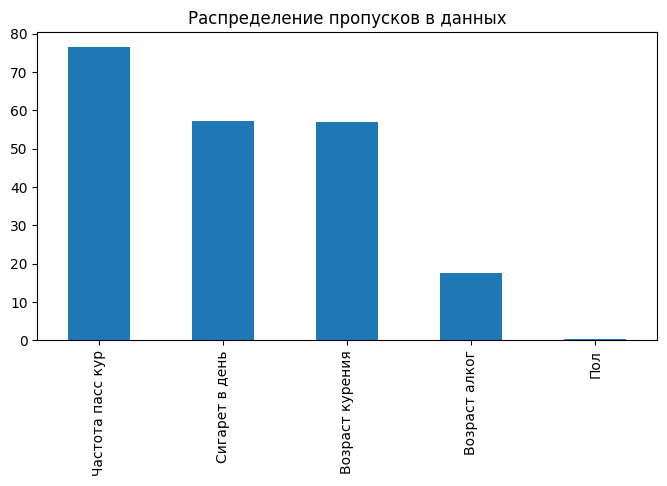

In [118]:
cols_with_null.plot(
    kind='bar',
    figsize=(8, 4),
    title='Распределение пропусков в данных'
);

#### Тепловая карта пропусков

Способ визуализации пропусков — тепловая карта

Для создания такой тепловой карты можно воспользоваться результатом метода **isnull()**. Ячейки таблицы, в которых есть пропуск, будем отмечать жёлтым цветом, а остальные — синим. Для этого создадим собственную палитру цветов тепловой карты с помощью метода color_palete() из библиотеки seaborn.

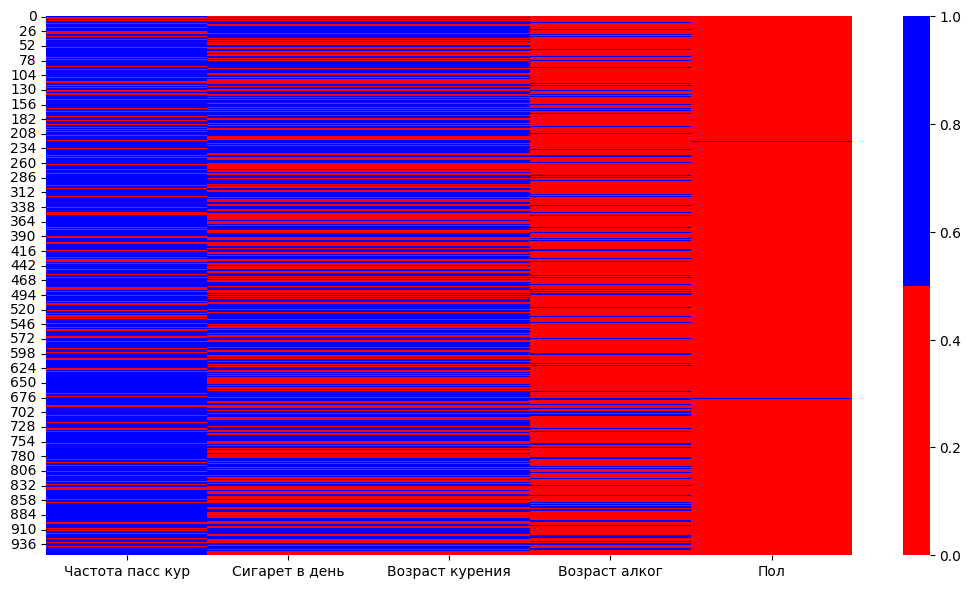

In [119]:
colors = ['red', 'blue']
fig = plt.figure(figsize=(13, 7))
cols = cols_with_null.index
ax = sns.heatmap(
    heart[cols].isnull(),
    cmap=sns.color_palette(colors),
)

На полученной тепловой карте не видим чётких процентных соотношений для числа пропусков в данных, однако мы можем увидеть места их концентрации в таблице. Например, видно, что признаки **Сигарет в день** и **Возраст курения** очень сильно связаны друг с другом по части пропусков: во всех записях, где хотя бы один не определён, не указан и второй (жёлтые линии для двух этих признаков полностью совпадают друг с другом).

#### **Работа с пропусками**

##### **1. Отбрасывание записей и признаков**

При использовании метода удаления придерживаться следующих правил: удаляется столбец, если число пропусков в нем более 30-40%. В остальных случаях удаляются записи.

Метод **dropna()**

***Основные параметры:***

* **axis** — ось, по которой производится удаление (по умолчанию 0 — строки).
* **how** — как производится удаление строк (any — если хотя бы в одном из столбцов есть пропуск, стоит по умолчанию; all — если во всех столбцах есть пропуски).
* **thresh** —  порог удаления. Определяет минимальное число непустых значений в строке/столбце, при котором она/он сохраняется. Например, если мы установим в thresh значение 2, то мы удалим строки, где число пропусков больше чем n-2, где n — число признаков (если axis=0).


Предварительно создадим копию исходной таблицы — drop_heart, чтобы не повредить её. Зададимся порогом в 70%: будем оставлять только те столбцы, в которых 70 и более процентов записей не являются пустыми. После этого удалим записи, в которых содержится хотя бы один пропуск.

In [120]:
#создаем копию исходной таблицы
drop_heart = heart.copy()
#задаем минимальный порог: вычисляем 70% от числа строк
thresh = drop_heart.shape[0]*0.7
#удаляем столбцы, в которых более 30% (100-70) пропусков
drop_heart = drop_heart.dropna(thresh=thresh, axis=1)#удаляем записи, в которых есть хотя бы 1 пропуск
drop_heart = drop_heart.dropna(how='any', axis=0)
#отображаем результирующую долю пропусков
drop_heart.isnull().mean()

,0
Бронхиальная астма,0.0
ЛПНП,0.0
Возраст алког,0.0
Работа,0.0
Статус Курения,0.0
Пассивное курение,0.0
Переломы,0.0
Время пробуждения,0.0
ЛПВП,0.0
Выход на пенсию,0.0


In [121]:
print(drop_heart.shape)

(787, 34)


##### **2. Заполнение недостающих значений константами**

Чаще всего пустые места заполняют средним/медианой/модой для числовых признаков и модальным значением для категориальных признаков. Cложность заключается в выборе метода заполнения. Важным фактором при выборе метода является распределение признаков с пропусками.

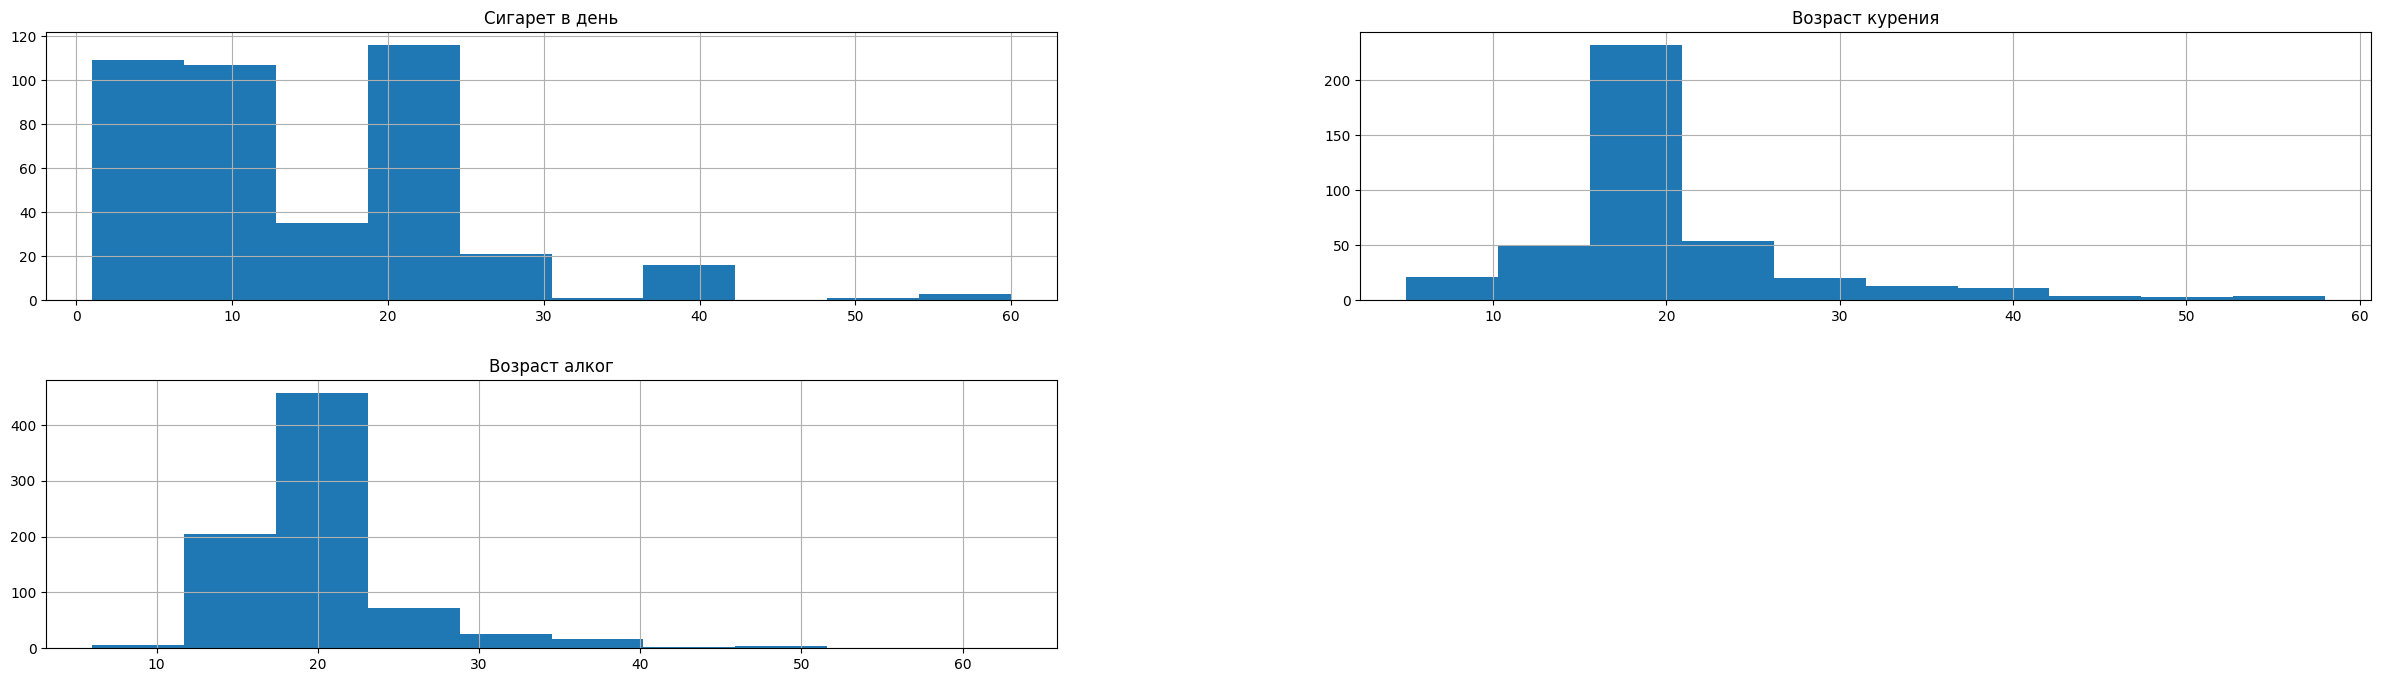

In [122]:
cols = cols_with_null.index
heart[cols].hist(figsize=(30, 8));

**Рекомендации**

 * Для **распределений, похожих на логнормальное**, где пик близ нуля, а далее наблюдается постепенный спад частоты, высока вероятность наличия выбросов. Среднее очень чувствительно к выбросам. Предпочтительнее использовать медианное значение для таких признаков.

* Если ***признак числовой и дискретный***, то их заполнение средним/медианой является ошибочным, так как может получиться число, которое не может являться значением этого признака. Такой признак заполняют либо модой, либо округляют до целого числа (или нужного количества знаков после запятой) среднее/медиану.
* **Категориальные признаки** заполняются либо модальным значением, либо, если вы хотите оставить информацию о пропуске в данных, значением 'unknown'.
* Иногда в данных бывает такой признак, основываясь на котором, можно заполнить пропуски в другом. Например, в наших данных это признак **Пассивное курение**.

У пациентов с нулевым значением в переменной **Пассивное курение** должны быть пропущены значения в столбцах **Частота пасс кур**. Проверим это.

In [123]:
# Проверяем условие, что если 'Пассивное курение' равно 0, то 'Частота пасс кур' должна быть NaN
condition = (heart['Пассивное курение'] == 0) & (heart['Частота пасс кур'].notna())

# Подсчитываем количество строк, где условие не выполняется
count_invalid_rows = condition.sum()

# Если условие выполняется для хотя бы одной строки, выводим соответствующее сообщение и индексы строк
if count_invalid_rows > 0:
    print('Есть строки, где "Пассивное курение" равно 0, но "Частота пасс кур" не является NaN.')
    print('Индексы этих строк:')
    print(heart.index[condition].tolist())
    print(f'Количество таких строк: {count_invalid_rows}')
else:
    print('Все строки корректны: если "Пассивное курение" равно 0, то "Частота пасс кур" равна NaN.')

Есть строки, где "Пассивное курение" равно 0, но "Частота пасс кур" не является NaN.
Индексы этих строк:
[392]
Количество таких строк: 1


Одна ошибка. У пациента с индексом 392 условие не выполняется. Изучим данного пациента.

In [124]:
print(heart.loc[392])

Бронхиальная астма                                                   0
ЛПНП                                                              1.94
Возраст алког                                                     20.0
Работа                                                               0
Статус Курения                                                   Курит
Пассивное курение                                                    0
Переломы                                                             0
Время пробуждения                                             09:00:00
ЛПВП                                                              1.11
Выход на пенсию                                                      0
Холестерин                                                         3.7
Артериальная гипертония                                              0
Триглицериды                                                      1.43
Гепатит                                                              0
Сахарн

Женщина курит с 19 лет 15 сигарет в день и указала, что частота пассивного курения 3-6 раз в неделю. Значит, ошибка в переменной ‘Пассивное курение’.
Заменим значение признака ‘Пассивное курение’ для пациента с индексом 392 на 1.

In [125]:
heart.loc[392, 'Пассивное курение'] = 1

Теперь всё правильно и мы можем заполнить эти пропуски нулями.

* Заполним пропуски в признаке **Частота пасс кур** нулями. Но так как признак является категорийным, поставим 0 как строку, заключив в кавычки. Иначе далее при кодировании признака эти нули снова будут рассматриваться как пропущенные значения.

Заполнение значений осуществляется с помощью метода **fillna()**.

Главный параметр метода — **value** (значение, заполняются данные в столбце). Если метод вызывается от имени всего DataFrame, то в качестве value можно использовать словарь, где ключи — названия столбцов таблицы, а значения словаря — заполняющие константы.

In [126]:
heart.fillna({'Частота пасс кур':'0'}, inplace=True)

Проверим отсутствуют ли значения в столбцах **Возраст курения** и **Сигарет в день** у людей, которые никогда не курили

In [127]:
# Находим строки, где 'Возраст курения' отсутствует
missing_smoking_age = heart['Возраст курения'].isna()

# Находим строки, где 'Сигарет в день' также отсутствует
missing_cigarettes_per_day = heart['Сигарет в день'].isna()

# Проверяем, есть ли строки, где 'Возраст курения' отсутствует и 'Сигарет в день' также отсутствует
if (missing_smoking_age & missing_cigarettes_per_day).any():
    print('Да, это правда!')

Да, это правда!


Мы можем заполнить эти пропуски, используя максимальное значение возраста (например, 90, что будет означать, что пациент начал курить только в 90 лет...точнее никогда не начнёт) для **Возраст курения** и ноль для **Сигарет в день**.

In [128]:
heart.fillna({'Возраст курения':90}, inplace=True)
heart.fillna({'Сигарет в день':0}, inplace=True)

Аналогично для переменной **Возраст алког**.

In [129]:
heart.fillna({'Возраст алког':90}, inplace=True)

* Вычислим сумму  пропущенных значений в каждом столбце.

    *   Метод **isna()** возвращает таблицу, состоящую из **True/False** для каждого
элемента, в зависимости от того находится ли там пропущенное значение (**NaN**).

    *   Метод **sum()** суммирует элементы в столбцах таблицы принимая **True** за **1**, а **False** за **0**.

In [130]:
heart.isna().sum()

,0
Бронхиальная астма,0
ЛПНП,0
Возраст алког,0
Работа,0
Статус Курения,0
Пассивное курение,0
Переломы,0
Время пробуждения,0
ЛПВП,0
Выход на пенсию,0


##### **Пол**

У 2-х пациентов неизвестен пол

* Выберем только строчки с данными о пациентах, у которого не указан пол

In [131]:
heart['Пол'].value_counts(dropna=False)

,count
Пол,
Ж,666
М,288
NaN,2


In [132]:
heart[heart['Пол'].isna()]

,Бронхиальная астма,ЛПНП,Возраст алког,Работа,Статус Курения,Пассивное курение,Переломы,Время пробуждения,ЛПВП,Выход на пенсию,...,Сон после обеда,Время засыпания,Хроническое заболевание легких,Сигарет в день,Образование,"Индекс массы тела, кг/м^2",Прекращение работы по болезни,Религия,Профессия,ССЗ
222,0,2.06,18.0,0,Никогда не курил(а),0,0,07:00:00,1.58,1,...,0,23:00:00,0,0.0,4 - профессиональное училище,21.9,0,Христианство,квалифицированные работники сельского хозяйств...,0
677,0,3.71,90.0,0,Никогда не курил(а),0,1,08:00:00,1.08,1,...,0,22:00:00,0,0.0,4 - профессиональное училище,32.6,0,Христианство,низкоквалифицированные работники,1


Можно закодировать пол самым часто встречающимся значением ( в нашем случае Ж), можем как 0,5, обозначив Ж как 0, а М как 1.

Недостаток метода - можно «нафантазировать» новые данные, которые не учитывают истинного распределения. В результате исказить исходное распределение признака, что может плохо сказаться на модели.

In [133]:
# Кодировка пола как 0.5:
# heart['Пол'] = heart['Пол'].map({'Ж': 0, 'М': 1})
# heart['Пол'].fillna(0.5, inplace=True)

* Так как пустых значений в признаке **Пол** меньше 1%, удалим из датасета строчки, в которой не указан пол пациента

In [134]:
heart.dropna(subset=['Пол'], axis=0, inplace=True)

* Проверим остались ли у нас пропущенные значения в данных

In [135]:
heart.isna().sum()

,0
Бронхиальная астма,0
ЛПНП,0
Возраст алког,0
Работа,0
Статус Курения,0
Пассивное курение,0
Переломы,0
Время пробуждения,0
ЛПВП,0
Выход на пенсию,0


Пропущенных значений нет

### ДУБЛИКАТЫ

**Дубликатами** называются записи, для которых значения (всех или большинства) признаков совпадают.

За дубликаты можно посчитать записи, у которых совпадают либо все признаки, либо только часть признаков.

Если в таблице есть столбец с уникальным идентификатором (ID), можно попробовать поискать дубликаты по нему: одинаковые записи могут иметь одинаковый ID:

код

**heart['ID'].nunique() == heart.shape[0]**

до удаления признака ID дал бы результат TRUE, что означало бы, что все значения являются уникальными, нет убликатов.

МЕТОД **duplicated()**

Возвращает булеву маску для фильтрации. Для записей, у которых совпадают признаки, переданные методу, он возвращает True, для остальных — False.

Параметр **subset** — список признаков, по которым производится поиск дубликатов.

По умолчанию используются все столбцы в DataFrame и ищутся полные дубликаты.

In [136]:
dupl_columns = list(heart.columns)
mask = heart.duplicated(subset=dupl_columns)
heart_duplicates = heart[mask]
print(f'Число найденных дубликатов: {heart_duplicates.shape[0]}')

Число найденных дубликатов: 1


Итак, у нас 1 полная копия другой записи.
Одинаковые записи не несут полезной информации, искажают реальную статистику. Модель несколько раз видит одно и то же наблюдение, подстраивается под него. Это может стать проблемой при обучении.

* Если дубликаты есть, необходимо от них избавиться

Для этого можно воспользоваться методом **drop_duplicates()**, который удаляет повторяющиеся записи из таблицы.
Для примера создадим новую таблицу heart1, которая будет версией исходной таблицы, очищенной от полных дубликатов

In [137]:
heart = heart.drop_duplicates(subset=dupl_columns)
print(f'Результирующее число записей: {heart.shape[0]}')

Результирующее число записей: 953


### ВЫБРОСЫ

Выброс — наблюдение, которое существенно отличается от общего распределения и от других данных.

Выбросами могут быть как действительно реальные отклонения в данных, так и ошибкой.

Поиск потенциальных выбросов с помощью визуализации. Для числового признака можно построить гистограмму или коробчатую диаграмму, чтобы найти выбросы.

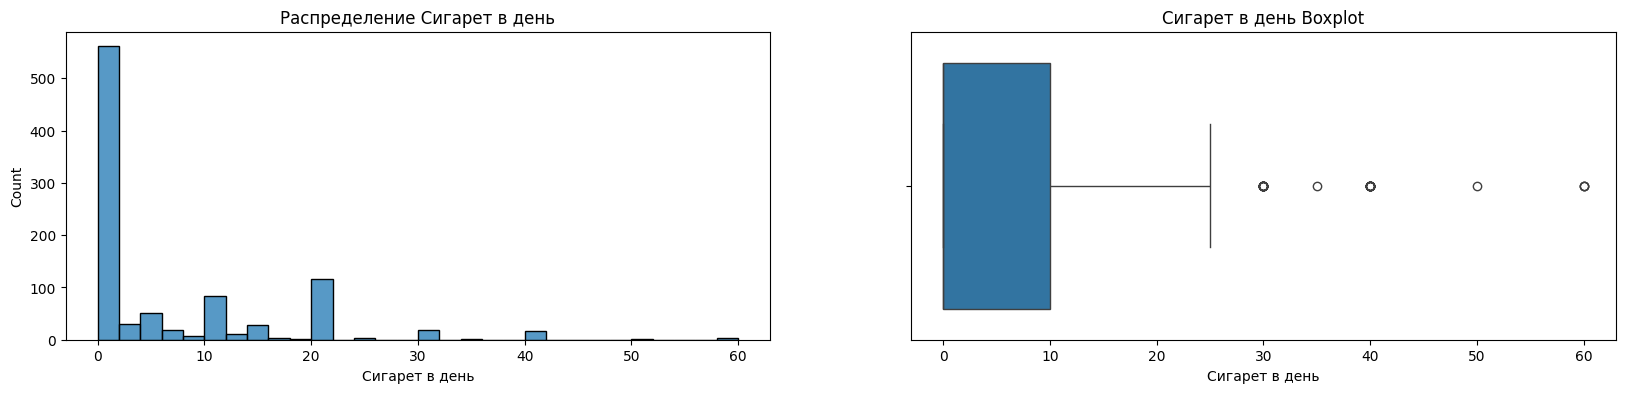

In [138]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 4))
histplot = sns.histplot(data=heart, x='Сигарет в день', ax=axes[0]);
histplot.set_title('Распределение Сигарет в день');
boxplot = sns.boxplot(data=heart, x='Сигарет в день', ax=axes[1]);
boxplot.set_title('Сигарет в день Boxplot');

Получили типичные графики распределений с выбросами в данных: коробчатая диаграмма, сплюснутая под весом выбросов, которая помогает увидеть выбросы, которые находятся за пределами усов (1.5 межквартильных размаха).

Визуализация помогает определить наличие выбросов. Для того чтобы их найти, можно воспользоваться статистическими подходами.

Одним из таких подходов является метод **межквартильного размаха** (**метод Тьюки**), который используется для построения коробчатой диаграммы.

##### **Метод межквартильного размаха (метод Тьюки)**

In [139]:
from IPython.display import Image

В соответствии с этим методом напишем функцию **outliers_iqr()**, которая принимает на вход DataFrame и признак, по которому ищутся выбросы, а затем возвращает потенциальные выбросы, найденные с помощью метода Тьюки, и очищенный от них датасет.

Квантили вычисляются с помощью метода **quantile()**. Потенциальные выбросы определяются при помощи фильтрации данных по условию выхода за пределы верхней или нижней границы.

In [140]:
def outliers_iqr(data, feature):
    x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75),
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * 1.5)
    upper_bound = quartile_3 + (iqr * 1.5)
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

Применим эту функцию к таблице **heart** и признаку **Сигарет в день**, а также выведем размерности результатов:



In [141]:
outliers, cleaned = outliers_iqr(heart, 'Сигарет в день')
print(f'Число выбросов по методу Тьюки: {outliers.shape[0]}')
print(f'Результирующее число записей: {cleaned.shape[0]}')

Число выбросов по методу Тьюки: 39
Результирующее число записей: 914


Согласно классическому методу Тьюки, под выбросы попали 39 записей в таблице. Построим гистограмму и коробчатую диаграмму на новых данных cleaned_heart:

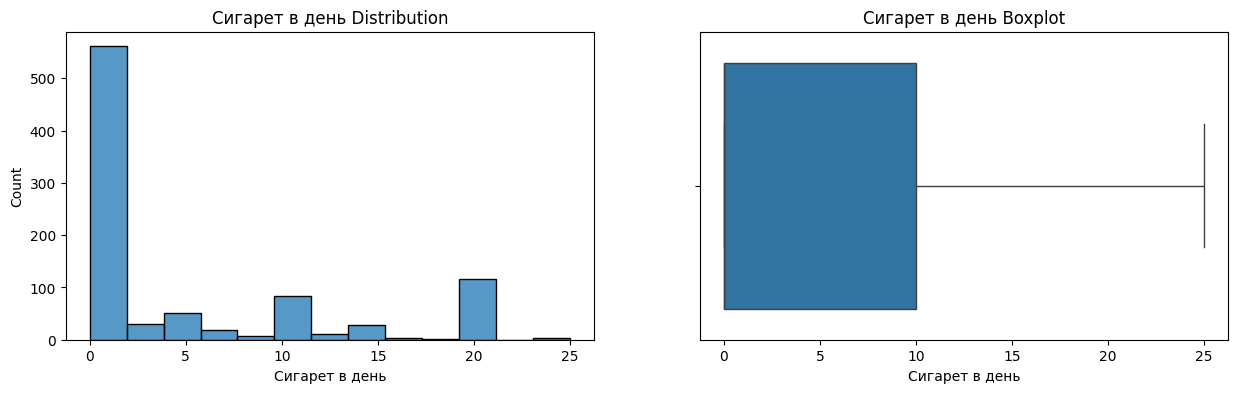

In [142]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=cleaned, x='Сигарет в день', ax=axes[0]);
histplot.set_title('Сигарет в день Distribution');
boxplot = sns.boxplot(data=cleaned, x='Сигарет в день', ax=axes[1]);
boxplot.set_title('Сигарет в день Boxplot');

После удаления выбросов квартили рассчитываются заново по новым данным, и из-за свойств распределения могут появиться новые точки, которые считаются выбросами, так как классический метод межквартильного размаха не учитывает особенностей распределения! Он требует, чтобы данные были распределены плюс-минус нормально (гистограмма должна быть похожа на колокол), и требует от распределения примерной симметричности (чтобы у гистограммы были одинаковые хвосты в обе стороны).

Модифицируем функцию outliers_iqr(data, feature). Добавим в неё параметры left и right, которые задают число IQR влево и вправо от границ ящика. Функция, как и раньше, будет возвращать потенциальные выбросы и очищенный DataFrame.

In [143]:
def outliers_iqr_mod(data, feature, left,right):
    x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75),
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * left)
    upper_bound = quartile_3 + (iqr * right)
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

Ослабим границы метода Тьюки справа и усилим их влево. Применим модифицированную функцию outliers_iqr_mod() к признаку full_sq из таблицы **Сигарет в день** данным с параметрами left=1 и right=4. Результаты работы поместим в переменные outliers и cleaned.

In [144]:
outliers, cleaned = outliers_iqr_mod(heart, 'Сигарет в день', left=1, right=2)
print(f'Число выбросов по методу Тьюки: {outliers.shape[0]}')
print(f'Результирующее число записей: {cleaned.shape[0]}')

Число выбросов по методу Тьюки: 21
Результирующее число записей: 932


Если мы построим гистограмму и коробчатую диаграмму на полученных данных, то увидим вот такую картинку:

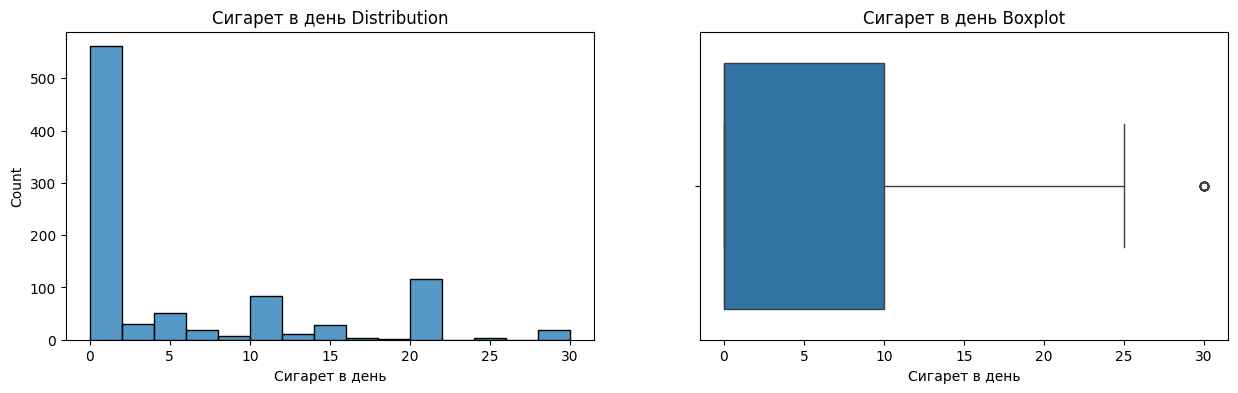

In [145]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=cleaned, x='Сигарет в день', ax=axes[0]);
histplot.set_title('Сигарет в день Distribution');
boxplot = sns.boxplot(data=cleaned, x='Сигарет в день', ax=axes[1]);
boxplot.set_title('Сигарет в день Boxplot');

### ОБРАБОТКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

Категориальные переменные требуют соответствующей **кодировки** для обработки в моделях машинного обучения.

* Закодируем признак **Пол**

In [146]:
heart['Пол'] = heart['Пол'].map({'М': 0, 'Ж': 1})

In [147]:
heart.head()

,Бронхиальная астма,ЛПНП,Возраст алког,Работа,Статус Курения,Пассивное курение,Переломы,Время пробуждения,ЛПВП,Выход на пенсию,...,Сон после обеда,Время засыпания,Хроническое заболевание легких,Сигарет в день,Образование,"Индекс массы тела, кг/м^2",Прекращение работы по болезни,Религия,Профессия,ССЗ
0,0,2.79,18.0,1,Курит,0,0,06:00:00,0.97,0,...,0,22:00:00,0,20.0,3 - средняя школа / закон.среднее / выше среднего,25.1,0,Христианство,низкоквалифицированные работники,0
1,0,6.62,90.0,0,Никогда не курил(а),0,1,04:00:00,0.74,0,...,1,00:00:00,0,0.0,5 - ВУЗ,35.2,0,Христианство,дипломированные специалисты,1
2,0,3.17,17.0,0,Никогда не курил(а),1,0,07:00:00,1.57,0,...,0,23:00:00,0,0.0,5 - ВУЗ,19.0,0,Христианство,дипломированные специалисты,0
3,0,2.74,13.0,1,Бросил(а),1,0,07:00:00,0.68,0,...,0,23:00:00,0,10.0,3 - средняя школа / закон.среднее / выше среднего,31.6,0,Атеист / агностик,низкоквалифицированные работники,1
4,0,6.62,16.0,0,Никогда не курил(а),1,1,06:00:00,1.01,0,...,0,23:00:00,0,0.0,3 - средняя школа / закон.среднее / выше среднего,32.8,1,Христианство,операторы и монтажники установок и машинного о...,1


* Исследуем признаки **Образование** и **Частота пасс кур**

In [148]:
for col in ['Образование', 'Частота пасс кур']:
    print(heart[col].value_counts(dropna=False))
    print()

Образование
4 - профессиональное училище                         452
5 - ВУЗ                                              313
3 - средняя школа / закон.среднее / выше среднего    181
2 - начальная школа                                    7
Name: count, dtype: int64

Частота пасс кур
0                         730
1-2 раза в неделю          92
4 и более раз в день       47
2-3 раза в день            30
не менее 1 раза в день     29
3-6 раз в неделю           25
Name: count, dtype: int64



Признаки **Образование** и **Частота пасс кур** являются ординальными.

**Ординарные признаки** (также известные как порядковые или ранговые) - это характеристики, которые можно упорядочить по степени или уровню. Они представляют собой шкалу, на которой объекты могут быть расположены в определенном порядке, например, от низкого к высокому или от слабого к сильному. Мы можем использовать этот порядок для кодирования.

* Заменим все уникальные значения переменной **Частота пасс кур** на числа

In [149]:
heart['Частота пасс кур'] = heart['Частота пасс кур'].map(
    {'0': 0,
     '1-2 раза в неделю': 1,
     '3-6 раз в неделю': 2,
     'не менее 1 раза в день': 3,
     '2-3 раза в день': 4,
     '4 и более раз в день': 5})

* Изменим тип переменной **Частота пасс кур** на целочисленный

In [150]:
heart['Частота пасс кур'] = heart['Частота пасс кур'].astype(int)

* Закодируем признак **Образование**

In [151]:
heart['Образование'] = heart['Образование'].str[:1].astype(int)

Так как образование указано в виде номер-название (например, 3 - средняя школа / закон.среднее / выше среднего), мы можем оставить только номер.

**.str[:1]** получает первый символ каждой строки, а **.astype(int)** преобразует полученные символы в целые числа (изначально они были строками).

* Посмотрим результат

In [152]:
for col in ['Образование', 'Частота пасс кур']:
    print(heart[col].value_counts(dropna=False))
    print()

Образование
4    452
5    313
3    181
2      7
Name: count, dtype: int64

Частота пасс кур
0    730
1     92
5     47
4     30
3     29
2     25
Name: count, dtype: int64



### ОБРАБОТКА ЧИСЛОВЫХ ПРИЗНАКОВ

Рассмотрим переменные **Время пробуждения** и **Время засыпания**

* Закодируем время пробуждения, как час от полуночи, а время засыпания, как час от полудня

In [153]:
heart['Время пробуждения'].head()

,Время пробуждения
0,06:00:00
1,04:00:00
2,07:00:00
3,07:00:00
4,06:00:00


In [154]:
heart['Время пробуждения'] = heart['Время пробуждения'].str[:2].astype(int)
heart['Время засыпания'] = (heart['Время засыпания'].str[:2].astype(int) + 12) % 24

В первой строке кода происходит преобразование первых двух символов каждого значения в столбце **Время пробуждения** в целые числа.

Вторая строка кода преобразует первые два символа каждого значения в столбце **Время засыпания** в целые числа, добавляет 12 к каждому значению, а затем берет остаток от деления на 24, т.е. преобразует значения в часы после полуночи.

In [155]:
heart['Время пробуждения'].head()

,Время пробуждения
0,6
1,4
2,7
3,7
4,6


* Добавим в датасет новый признак - **Продолжительность сна**

In [156]:
heart['Продолжительность сна'] = heart['Время пробуждения'] - heart['Время засыпания'] + 1

* Посмотрим что у нас получилось

In [157]:
heart.head(5)

,Бронхиальная астма,ЛПНП,Возраст алког,Работа,Статус Курения,Пассивное курение,Переломы,Время пробуждения,ЛПВП,Выход на пенсию,...,Время засыпания,Хроническое заболевание легких,Сигарет в день,Образование,"Индекс массы тела, кг/м^2",Прекращение работы по болезни,Религия,Профессия,ССЗ,Продолжительность сна
0,0,2.79,18.0,1,Курит,0,0,6,0.97,0,...,10,0,20.0,3,25.1,0,Христианство,низкоквалифицированные работники,0,-3
1,0,6.62,90.0,0,Никогда не курил(а),0,1,4,0.74,0,...,12,0,0.0,5,35.2,0,Христианство,дипломированные специалисты,1,-7
2,0,3.17,17.0,0,Никогда не курил(а),1,0,7,1.57,0,...,11,0,0.0,5,19.0,0,Христианство,дипломированные специалисты,0,-3
3,0,2.74,13.0,1,Бросил(а),1,0,7,0.68,0,...,11,0,10.0,3,31.6,0,Атеист / агностик,низкоквалифицированные работники,1,-3
4,0,6.62,16.0,0,Никогда не курил(а),1,1,6,1.01,0,...,11,0,0.0,3,32.8,1,Христианство,операторы и монтажники установок и машинного о...,1,-4


In [158]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
Index: 953 entries, 0 to 954
Data columns (total 38 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Бронхиальная астма                      953 non-null    int64  
 1   ЛПНП                                    953 non-null    float64
 2   Возраст алког                           953 non-null    float64
 3   Работа                                  953 non-null    int64  
 4   Статус Курения                          953 non-null    object 
 5   Пассивное курение                       953 non-null    int64  
 6   Переломы                                953 non-null    int64  
 7   Время пробуждения                       953 non-null    int64  
 8   ЛПВП                                    953 non-null    float64
 9   Выход на пенсию                         953 non-null    int64  
 10  Холестерин                              953 non-null    float64
 11

Больше нет пропущенных значений. Осталось 6 категориальных признаков. Но прежде чем их кодировать, посмотрим корреляционные зависимости между всеми числовыми признаками.

In [159]:
heart.corr(numeric_only=True).round(2)

,Бронхиальная астма,ЛПНП,Возраст алког,Работа,Пассивное курение,Переломы,Время пробуждения,ЛПВП,Выход на пенсию,Холестерин,...,"Абдоминальное ожирение, см",Сон после обеда,Время засыпания,Хроническое заболевание легких,Сигарет в день,Образование,"Индекс массы тела, кг/м^2",Прекращение работы по болезни,ССЗ,Продолжительность сна
Бронхиальная астма,1.00,0.06,-0.01,-0.06,0.00,0.03,-0.02,-0.01,0.06,0.07,...,0.04,-0.02,0.03,0.23,-0.09,-0.11,0.07,0.00,0.08,-0.04
ЛПНП,0.06,1.00,0.04,-0.15,-0.00,0.12,-0.01,-0.33,0.18,0.95,...,0.58,0.06,-0.08,0.06,0.04,-0.07,0.58,0.07,0.69,0.05
Возраст алког,-0.01,0.04,1.00,-0.08,-0.03,-0.04,-0.09,0.04,0.08,0.08,...,-0.04,-0.01,0.03,0.00,-0.19,-0.04,0.06,0.03,0.04,-0.11
Работа,-0.06,-0.15,-0.08,1.00,0.05,-0.06,-0.16,0.07,-0.74,-0.19,...,-0.10,-0.15,-0.05,0.00,0.09,0.14,-0.19,-0.24,-0.22,-0.11
Пассивное курение,0.00,-0.00,-0.03,0.05,1.00,-0.04,-0.00,0.09,-0.03,0.01,...,0.06,-0.05,-0.04,-0.04,-0.09,-0.02,0.03,0.02,0.02,0.03
Переломы,0.03,0.12,-0.04,-0.06,-0.04,1.00,-0.01,-0.15,0.07,0.12,...,0.17,0.05,0.01,0.07,0.07,-0.08,0.12,0.01,0.12,-0.02
Время пробуждения,-0.02,-0.01,-0.09,-0.16,-0.00,-0.01,1.00,0.05,0.10,-0.02,...,-0.01,-0.01,0.30,-0.10,-0.06,0.05,-0.03,0.04,-0.00,0.67
ЛПВП,-0.01,-0.33,0.04,0.07,0.09,-0.15,0.05,1.00,-0.09,-0.45,...,-0.67,-0.11,-0.03,-0.03,-0.29,0.17,-0.57,-0.06,-0.58,0.06
Выход на пенсию,0.06,0.18,0.08,-0.74,-0.03,0.07,0.10,-0.09,1.00,0.22,...,0.14,0.11,0.01,-0.00,-0.14,-0.12,0.22,-0.07,0.25,0.08
Холестерин,0.07,0.95,0.08,-0.19,0.01,0.12,-0.02,-0.45,0.22,1.00,...,0.59,0.04,-0.07,0.07,-0.05,-0.05,0.62,0.07,0.78,0.04


(32.5, -0.5)

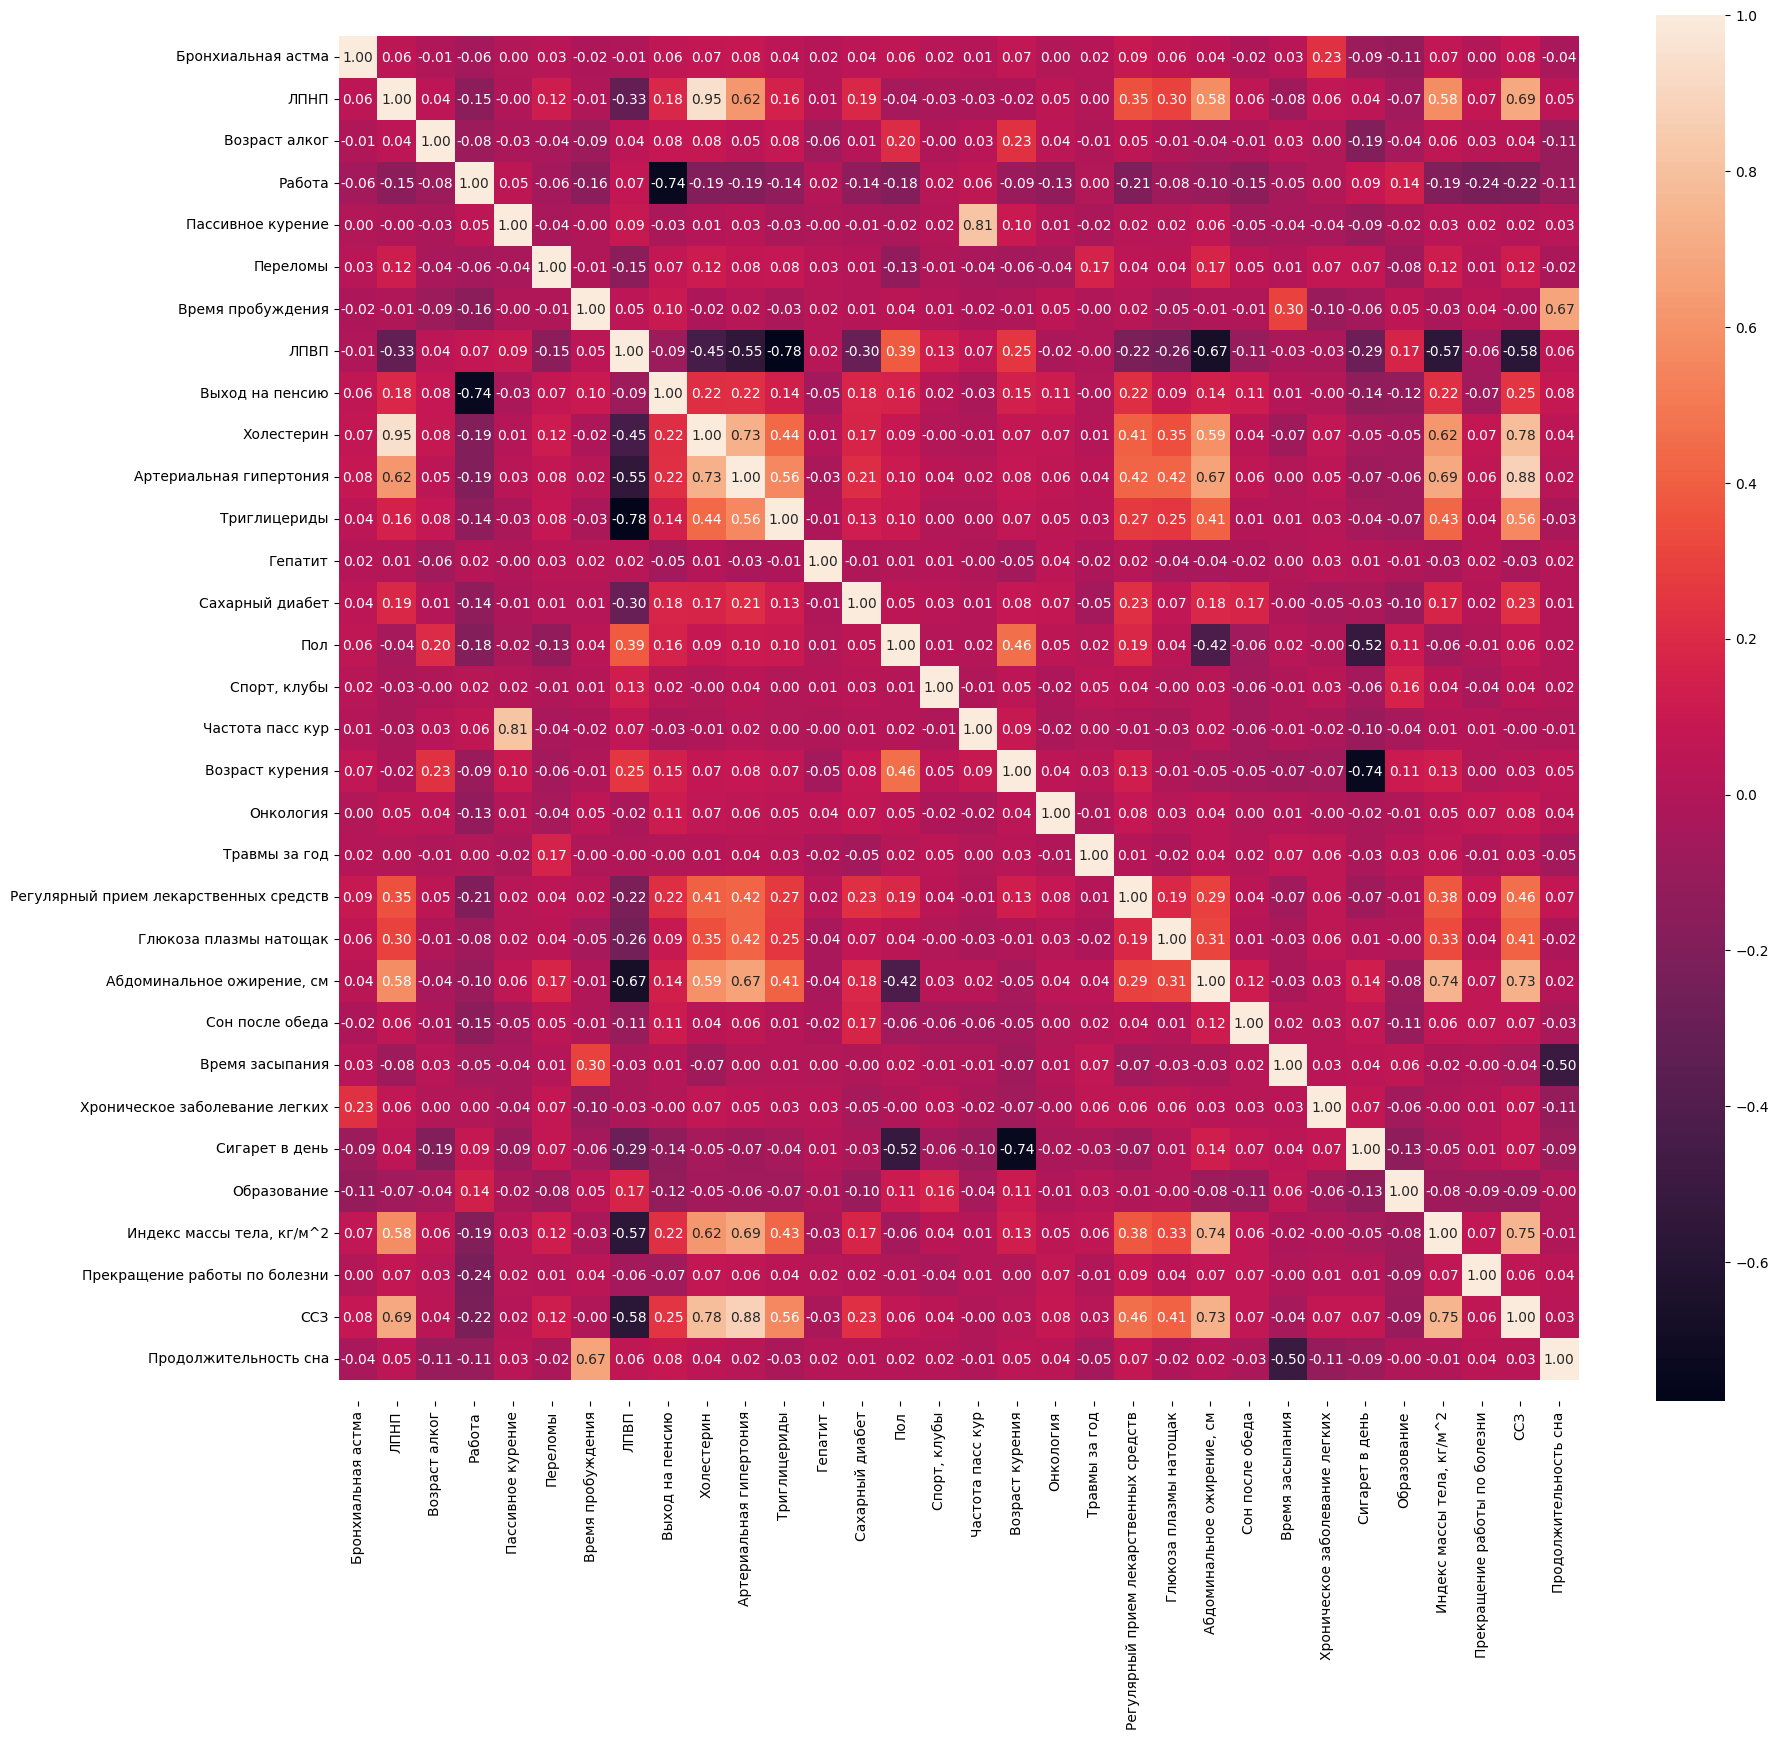

In [160]:
plt.figure(figsize = (20,18))
# heart.corr(numeric_only=True): вычисляет корреляционную матрицу для числовых столбцов DataFrame heart
# annot=True: отображает числовые значения корреляций на тепловой карте
# fmt=".2f": определяет формат числовых значений, отображаемых на тепловой карте (2 знака после запятой)
ax = sns.heatmap(heart.corr(numeric_only=True), annot = True, fmt = ".2f")
# Получаем текущие границы оси Y
i, k = ax.get_ylim()
# Сужаем диапазон оси Y
ax.set_ylim(i+0.5, k-0.5)

In [161]:
corr = heart.corr(numeric_only=True).round(4)
m = (corr.mask(np.eye(len(corr), dtype=bool)).abs() > 0.8).any()
raw = corr.loc[m, m]
raw

,ЛПНП,Пассивное курение,Холестерин,Артериальная гипертония,Частота пасс кур,ССЗ
ЛПНП,1.0000,-0.0008,0.9460,0.6239,-0.0255,0.6903
Пассивное курение,-0.0008,1.0000,0.0068,0.0281,0.8134,0.0151
Холестерин,0.9460,0.0068,1.0000,0.7296,-0.0069,0.7847
Артериальная гипертония,0.6239,0.0281,0.7296,1.0000,0.0206,0.8777
Частота пасс кур,-0.0255,0.8134,-0.0069,0.0206,1.0000,-0.0027
ССЗ,0.6903,0.0151,0.7847,0.8777,-0.0027,1.0000


Признаки **Пассивное курение** и **Частота пасс кур**

**Холестерин** и **ЛПНП**

сильно коррелируют. Удалим один из них


In [162]:
heart = heart.drop(columns=["Пассивное курение", "ЛПНП"], axis=1)

In [163]:
heart.shape

(953, 36)

In [164]:
heart.columns

Index(['Бронхиальная астма', 'Возраст алког', 'Работа', 'Статус Курения',
       'Переломы', 'Время пробуждения', 'ЛПВП', 'Выход на пенсию',
       'Холестерин', 'Артериальная гипертония', 'Триглицериды', 'Гепатит',
       'Сахарный диабет', 'Пол', 'Спорт, клубы', 'Семья', 'Частота пасс кур',
       'Возраст курения', 'Онкология', 'Травмы за год',
       'Регулярный прием лекарственных средств', 'Национальность', 'Алкоголь',
       'Глюкоза плазмы натощак', 'Абдоминальное ожирение, см',
       'Сон после обеда', 'Время засыпания', 'Хроническое заболевание легких',
       'Сигарет в день', 'Образование', 'Индекс массы тела, кг/м^2',
       'Прекращение работы по болезни', 'Религия', 'Профессия', 'ССЗ',
       'Продолжительность сна'],
      dtype='object')

Осталось 6 категориальных признаков: **Семья**, **Национальность**, **Религия**, **Профессия**, **Статус Курения** и **Алкоголь**.

Для их кодирования можно использовать:

1) класс **OneHotEncoder** из библиотеки **sklearn.preprocessing**

2) **кодирование по популярности**  с  добавлением в закодированные значения небольшого уровня шума, чтобы различать категории с одинаковой популярностью


* Рассмотрим подробнее какие уникальные значения имеют 6 категориальных переменных, которые нам необходимо закодировать числовыми значениями

In [165]:
for col in ['Семья', 'Национальность', 'Религия', 'Профессия', 'Статус Курения', 'Алкоголь']:
    print(heart[col].value_counts(dropna=False))
    print()

Семья
в браке в настоящее время                          563
вдовец / вдова                                     142
в разводе                                          124
гражданский брак / проживание с партнером           79
никогда не был(а) в браке                           43
раздельное проживание (официально не разведены)      2
Name: count, dtype: int64

Национальность
Русские                  897
Татары                    18
Немцы                      6
Чуваши                     5
Азербайджанцы              4
Украинцы                   4
Мордва                     2
Другие национальности      2
Казахи                     2
Киргизы                    2
Евреи                      2
Таджики                    2
Армяне                     2
Эстонцы                    1
Молдаване                  1
Белорусы                   1
Башкиры                    1
Буряты                     1
Name: count, dtype: int64

Религия
Христианство         802
Атеист / агностик     86
Нет            

* Посчитаем сколько уникальных значений имеет категориальные признаки

In [166]:
columns_to_change = ['Семья', 'Национальность', 'Религия', 'Профессия', 'Статус Курения', 'Алкоголь']
for column in columns_to_change:
 print('Число уникальных значений признака {}: '.format(column), heart[column].nunique())

Число уникальных значений признака Семья:  6
Число уникальных значений признака Национальность:  18
Число уникальных значений признака Религия:  4
Число уникальных значений признака Профессия:  11
Число уникальных значений признака Статус Курения:  3
Число уникальных значений признака Алкоголь:  3


##### Кодирования категориальных признаков - **по популярности**

* Закодируем признаки по популярности с добавлением в закодированные значения небольшого уровня шума, чтобы различать категории с одинаковой популярностью

In [167]:
np.random.seed(42)
cats = ['Семья', 'Национальность', 'Религия', 'Профессия', 'Статус Курения', 'Алкоголь']
for cat in cats:
    heart[cat] = heart[cat].map(heart[cat].value_counts()) + 0.1 * np.random.random(len(heart))

**np.random.seed(42)** - устанавливает начальное значение для генератора случайных чисел в библиотеке NumPy. Это гарантирует, что каждый раз, когда код выполняется, он будет генерировать одни и те же случайные числа, что полезно для воспроизводимости результатов.

**cats = ['Семья', 'Национальность', 'Религия', 'Профессия', 'Статус Курения', 'Алкоголь']** - создает список категорий, которые будут закодированы.

**for cat in cats:** - начинает цикл, который будет проходить по каждой категории в списке **cats**.

 **heart[cat].map(heart[cat].value_counts())** - применяет функцию **value_counts()** к столбцу **heart[cat]** и использует результат для создания нового столбца.

 **+ 0.1 * np.random.random(len(heart)))** - добавляет к каждому значению в новом столбце случайное число, умноженное на 0.1. Это добавляет шум к кодированию, чтобы различать категории с одинаковой популярностью.

* Посмотрим результат данной кодировки

In [168]:
heart[cats].head()

,Семья,Национальность,Религия,Профессия,Статус Курения,Алкоголь
0,563.037454,897.091441,802.095807,137.017522,221.022652,633.099214
1,124.095071,897.041877,802.036794,225.086677,541.061397,164.085753
2,563.073199,897.038314,802.032693,225.028248,541.025286,633.009737
3,563.059866,897.051892,86.014889,137.095046,191.057763,633.070637
4,563.015602,897.004697,802.030560,72.058162,541.035921,633.034558


In [169]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
Index: 953 entries, 0 to 954
Data columns (total 36 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Бронхиальная астма                      953 non-null    int64  
 1   Возраст алког                           953 non-null    float64
 2   Работа                                  953 non-null    int64  
 3   Статус Курения                          953 non-null    float64
 4   Переломы                                953 non-null    int64  
 5   Время пробуждения                       953 non-null    int64  
 6   ЛПВП                                    953 non-null    float64
 7   Выход на пенсию                         953 non-null    int64  
 8   Холестерин                              953 non-null    float64
 9   Артериальная гипертония                 953 non-null    int64  
 10  Триглицериды                            953 non-null    float64
 11

In [170]:
heart.corr(numeric_only=True).round(2)

,Бронхиальная астма,Возраст алког,Работа,Статус Курения,Переломы,Время пробуждения,ЛПВП,Выход на пенсию,Холестерин,Артериальная гипертония,...,Время засыпания,Хроническое заболевание легких,Сигарет в день,Образование,"Индекс массы тела, кг/м^2",Прекращение работы по болезни,Религия,Профессия,ССЗ,Продолжительность сна
Бронхиальная астма,1.00,-0.01,-0.06,0.07,0.03,-0.02,-0.01,0.06,0.07,0.08,...,0.03,0.23,-0.09,-0.11,0.07,0.00,0.01,-0.04,0.08,-0.04
Возраст алког,-0.01,1.00,-0.08,0.22,-0.04,-0.09,0.04,0.08,0.08,0.05,...,0.03,0.00,-0.19,-0.04,0.06,0.03,0.05,0.04,0.04,-0.11
Работа,-0.06,-0.08,1.00,-0.08,-0.06,-0.16,0.07,-0.74,-0.19,-0.19,...,-0.05,0.00,0.09,0.14,-0.19,-0.24,-0.03,0.09,-0.22,-0.11
Статус Курения,0.07,0.22,-0.08,1.00,-0.05,-0.01,0.23,0.13,0.06,0.08,...,-0.07,-0.06,-0.72,0.10,0.15,0.01,0.09,0.13,0.02,0.04
Переломы,0.03,-0.04,-0.06,-0.05,1.00,-0.01,-0.15,0.07,0.12,0.08,...,0.01,0.07,0.07,-0.08,0.12,0.01,-0.03,-0.08,0.12,-0.02
Время пробуждения,-0.02,-0.09,-0.16,-0.01,-0.01,1.00,0.05,0.10,-0.02,0.02,...,0.30,-0.10,-0.06,0.05,-0.03,0.04,0.06,-0.02,-0.00,0.67
ЛПВП,-0.01,0.04,0.07,0.23,-0.15,0.05,1.00,-0.09,-0.45,-0.55,...,-0.03,-0.03,-0.29,0.17,-0.57,-0.06,0.01,0.13,-0.58,0.06
Выход на пенсию,0.06,0.08,-0.74,0.13,0.07,0.10,-0.09,1.00,0.22,0.22,...,0.01,-0.00,-0.14,-0.12,0.22,-0.07,0.05,-0.06,0.25,0.08
Холестерин,0.07,0.08,-0.19,0.06,0.12,-0.02,-0.45,0.22,1.00,0.73,...,-0.07,0.07,-0.05,-0.05,0.62,0.07,0.06,-0.05,0.78,0.04
Артериальная гипертония,0.08,0.05,-0.19,0.08,0.08,0.02,-0.55,0.22,0.73,1.00,...,0.00,0.05,-0.07,-0.06,0.69,0.06,0.08,-0.05,0.88,0.02


(36.5, -0.5)

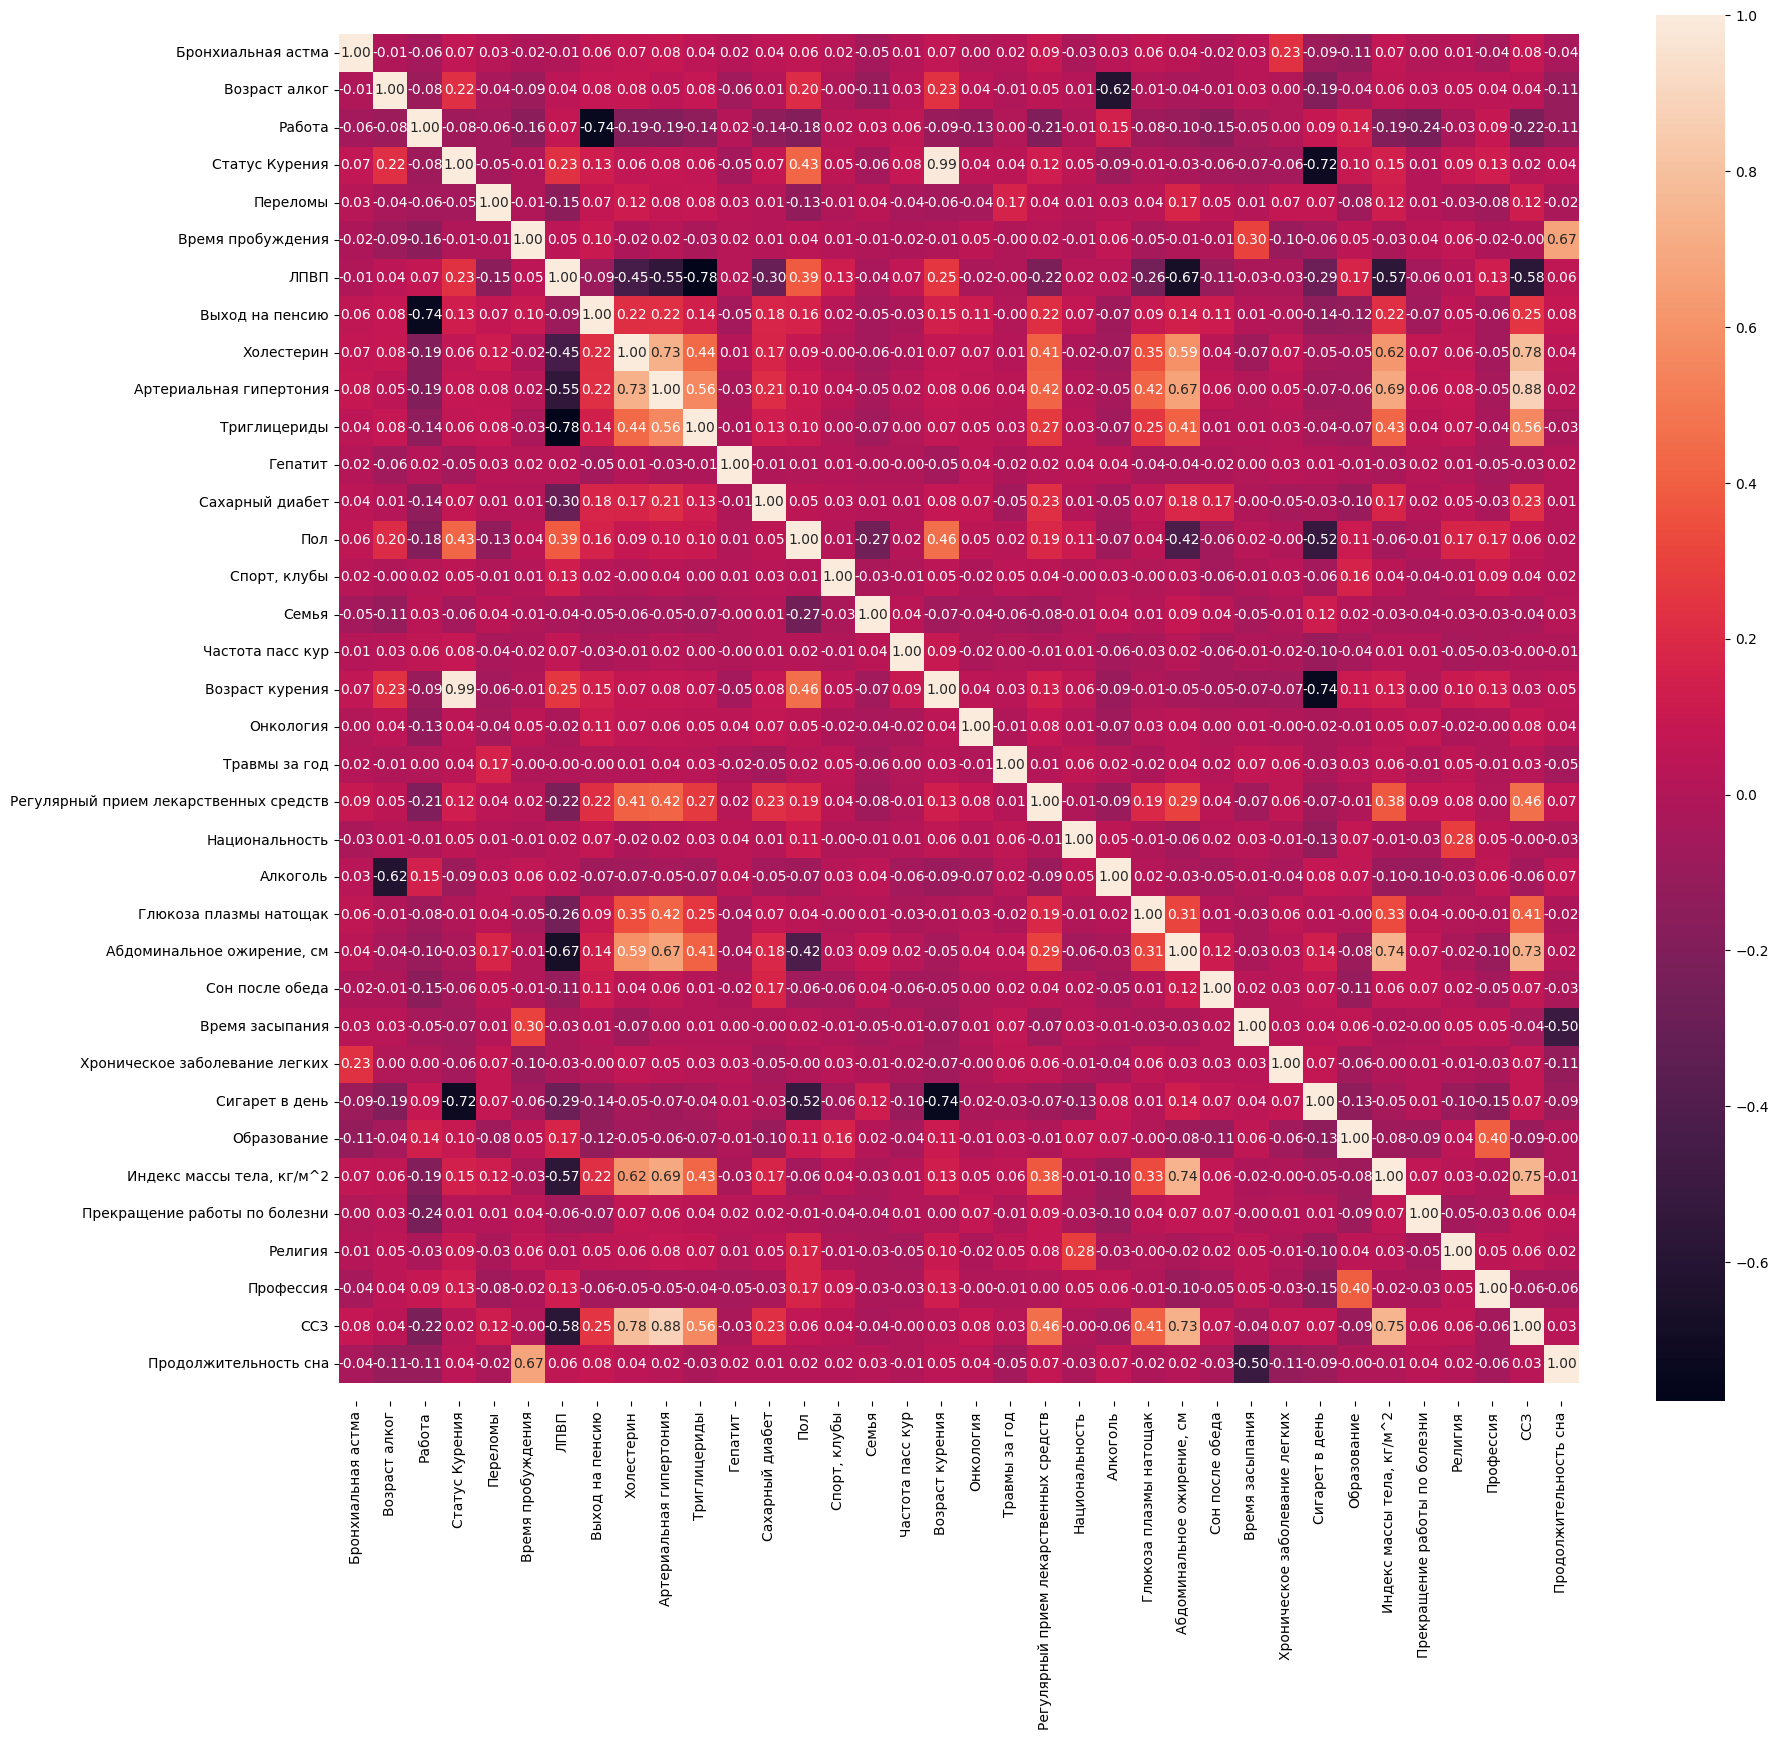

In [171]:
plt.figure(figsize = (20,18))
ax = sns.heatmap(heart.corr(numeric_only=True), annot = True, fmt = ".2f")
i, k = ax.get_ylim()
ax.set_ylim(i+0.5, k-0.5)

In [172]:
corr = heart.corr(numeric_only=True)
m = (corr.mask(np.eye(len(corr), dtype=bool)).abs() > 0.8).any()
raw = corr.loc[m, m]
raw

,Статус Курения,Артериальная гипертония,Возраст курения,ССЗ
Статус Курения,1.000000,0.079144,0.987525,0.021344
Артериальная гипертония,0.079144,1.000000,0.082417,0.877677
Возраст курения,0.987525,0.082417,1.000000,0.026417
ССЗ,0.021344,0.877677,0.026417,1.000000


In [174]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
Index: 953 entries, 0 to 954
Data columns (total 36 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Бронхиальная астма                      953 non-null    int64  
 1   Возраст алког                           953 non-null    float64
 2   Работа                                  953 non-null    int64  
 3   Статус Курения                          953 non-null    float64
 4   Переломы                                953 non-null    int64  
 5   Время пробуждения                       953 non-null    int64  
 6   ЛПВП                                    953 non-null    float64
 7   Выход на пенсию                         953 non-null    int64  
 8   Холестерин                              953 non-null    float64
 9   Артериальная гипертония                 953 non-null    int64  
 10  Триглицериды                            953 non-null    float64
 11

* Удалим одну из сильно коррелирующих переменных

In [ ]:
heart.drop('Статус Курения', axis=1, inplace=True)

# 2. ИССЛЕДОВАНИЕ ДАТАСЕТА

# СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ

In [92]:
from scipy import stats
from scipy.stats import norm
import scipy.stats as scs
import statsmodels.stats.diagnostic as sm
import statsmodels.api as sml
from statsmodels import stats as sms
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu, shapiro, fisher_exact, bartlett
! pip install scikit-posthocs -q
import scikit_posthocs as sp

## **Гипотеза 1** о влиянии сахарного диабета на риск развития ССЗ


H₀: Наличие сахарного диабета не влияет на развитие сердечно-сосудистого заболевания

H₁: Пациенты с сахарным диабетом имеют повышенный риск развития сердечно-сосудистого заболевания

In [175]:
contingency_table = pd.crosstab(heart['Сахарный диабет'], heart['ССЗ'])
print("Таблица сопряженности:")
print(contingency_table)

# Точный тест Фишера
from scipy.stats import fisher_exact

odds_ratio, p_fisher = fisher_exact(contingency_table)

# Хи-квадрат
chi2, p_chi2, dof, _ = chi2_contingency(contingency_table)

print(f"\nТочный тест Фишера:")
print(f"OR: {odds_ratio:.3f}")
print(f"p-value: {p_fisher:.4f}")

print(f"\nТест хи-квадрат:")
print(f"χ²({dof}) = {chi2:.3f}, p-value = {p_chi2:.4f}")

if p_chi2 < 0.05:
    print(f"\nВывод: Нулевая гипотеза отвергается. Различия между группами статистически значимы")
else:
    print(f"\nВывод: Статистически значимых различий между группами не выявлено")

Таблица сопряженности:
ССЗ                0    1
Сахарный диабет          
0                416  436
1                 12   89

Точный тест Фишера:
OR: 7.076
p-value: 0.0000

Тест хи-квадрат:
χ²(1) = 48.333, p-value = 0.0000

Вывод: Нулевая гипотеза отвергается. Различия между группами статистически значимы


OR — отношение шансов.

OR = 7.045 говорит, что у людей с диабетом шансы иметь ССЗ примерно в 7 раз выше, чем у людей без диабета.
p-value: 0.0000 — очень маленькое значение p. Меньше, чем заданный p-уровень значимости (0,05). Нулевую гипотезу отклоняем и заключаем, что связь между переменными существует.

**Вывод:** пациенты с сахарным диабетом имеют повышенный риск развития сердечно-сосудистого заболевания

## **Гипотеза 2** о влиянии признака Индекс массы тела, кг/м^2 на ССЗ

H₀: нет статистически значимых отличий признака ИМТ у пациентов с ССЗ и пациентов без ССЗ

* Среднее значение признака Индекс массы тела, кг/м^2 у пациентов с сердечно-сосудистыми заболеваниями равно среднему значению признака Индекс массы тела, кг/м^2 у пациентов без сердечно-сосудистых заболеваний.

* Нет статистически значимого различия между двумя группами по признаку “Индекс массы тела, кг/м^2”.

H₁: ИМТ у пациентов с ССЗ и пациентов без ССЗ имеют статистически значимые отличия

/tmp/ipykernel_1924/1357702014.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(heart['Индекс массы тела, кг/м^2'], fit=norm, ax=axes[0]);


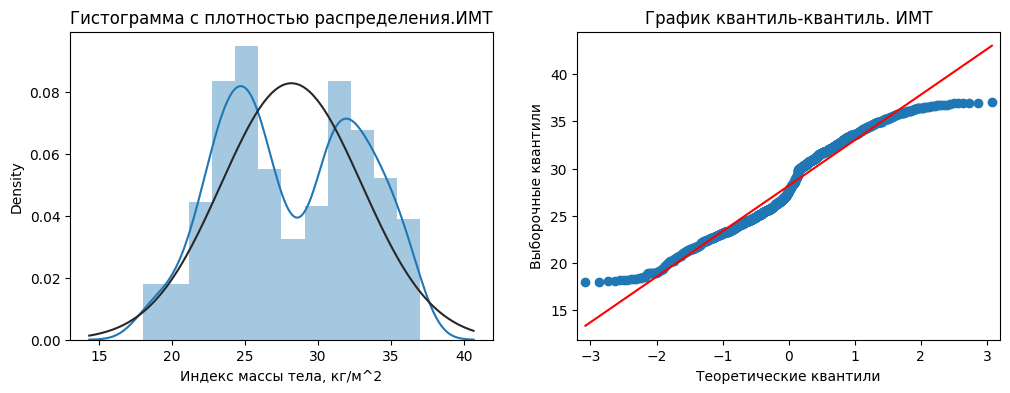

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.distplot(heart['Индекс массы тела, кг/м^2'], fit=norm, ax=axes[0]);
sml.qqplot(heart['Индекс массы тела, кг/м^2'], line='s', ax=axes[1])
axes[0].set_title('Гистограмма с плотностью распределения.ИМТ')
axes[1].set_title('График квантиль-квантиль. ИМТ')
axes[1].set_xlabel('Теоретические квантили')
axes[1].set_ylabel('Выборочные квантили');

In [180]:
# Проведение теста Шапиро-Уилка для проверки на нормальность данных
statistic, p_value = shapiro(heart['Индекс массы тела, кг/м^2'])

# Вывод результатов
print("Значение статистики теста Шапиро-Уилка:", statistic)
print("p-value:", p_value)

alpha = 0.05
if p_value > alpha:
    print("Данные распределены примерно нормально")
else:
    print("Данные НЕ распределены нормально")

Значение статистики теста Шапиро-Уилка: 0.9610265361085899
p-value: 2.966312028858608e-15
Данные НЕ распределены нормально


Данные не распределены нормально, значит нет необходимости в проверке однородности дисперсий. Выбираем непараметрический тест Манна-Уитни

In [182]:
g0 = heart.loc[heart['ССЗ'] == 0, 'Индекс массы тела, кг/м^2'].dropna().values
g1 = heart.loc[heart['ССЗ'] == 1, 'Индекс массы тела, кг/м^2'].dropna().values

u_stat, p_val = stats.mannwhitneyu(g0, g1, alternative='two-sided')

# Вывод результатов
print("Значение статистики:", u_stat)
print("Значение p-value:", p_val)

if p_val < 0.05:
    print("Различия между группами статистически значимы")
else:
    print("Статистически значимых различий между группами не выявлено")

Значение статистики: 17737.0
Значение p-value: 5.386141132463236e-111
Различия между группами статистически значимы


**Выводы:** Существует статистически значимая зависимость между ИМТ  и ССЗ. Таким образом, Показатель Индекс массы тела влияет на наличие сердечно-сосудистых заболеваний

Проверьте зависимость признаков Холестерин и ССЗ

Н0: нет влияния признака Холестерина на ССЗ.

Н1: Признак Холестерина влияет на развитие ССЗ.

In [183]:
g0 = heart.loc[heart['ССЗ'] == 0, 'Холестерин'].dropna().values
g1 = heart.loc[heart['ССЗ'] == 1, 'Холестерин'].dropna().values

u_stat, p_val = stats.mannwhitneyu(g0, g1, alternative='two-sided')

# Вывод результатов
print("Значение статистики:", u_stat)
print("Значение p-value:", p_val)

if p_val < 0.05:
    print("Различия между группами статистически значимы")
else:
    print("Статистически значимых различий между группами не выявлено")

Значение статистики: 5413.5
Значение p-value: 2.5182394599130124e-141
Различия между группами статистически значимы


**Выводы:** Существует статистически значимая зависимость между Холестерином  и ССЗ. Таким образом, Показатель Холестерина влияет на наличие ССЗ.

Проверьте зависимость признаков Статус Курения и ССЗ

Воспользуемся Критерием Краскела-Уолиса

In [184]:
levels = sorted(heart['Статус Курения'].dropna().unique().tolist())
groups = [heart.loc[heart['Статус Курения'] == lvl, 'ССЗ'].dropna().values for lvl in levels]

h_stat, p_val = stats.kruskal(*groups)
# Вывод результатов
print("Значение статистики:", h_stat)
print("Значение p-value:", p_val)

if p_val < 0.05:
    print("Различия между группами статистически значимы")
else:
    print("Статистически значимых различий между группами не выявлено")

Значение статистики: 951.9999999999997
Значение p-value: 0.4939047660476001
Статистически значимых различий между группами не выявлено


**Выводы**: Статус курения не влияет на ССЗ. p-value > 0.05

# МАШИННОЕ ОБУЧЕНИЕ

In [185]:
from sklearn.linear_model import LogisticRegression    # Импорт модели логистической регрессии
from sklearn.neighbors import KNeighborsClassifier     # Импорт классификатора K-ближайших соседей
from sklearn.tree import DecisionTreeClassifier        # Импорт классификатора на основе дерева решений
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn import metrics      # Импорт всего модуля metrics для работы с метриками оценки моделей
from sklearn.metrics import  (    # Импорт конкретных функций оценки из подмодуля metrics
    accuracy_score,              # Импорт функции для оценки точности (accuracy) модели, т.е. доли правильно предсказанных примеров
    balanced_accuracy_score,     # Импорт функции для оценки сбалансированной точности, учитывающей классовую неоднородность
    precision_score,             # Импорт функции для вычисления точности (precision)
    recall_score,                # Импорт функции для вычисления полноты (recall)
    confusion_matrix,            # Импорт функции для создания матрицы ошибок (confusion matrix):TN, TP, FN, FP
    multilabel_confusion_matrix, # Импорт функции для создания матрицы ошибок для случаев с многомерной классификацией
    f1_score,                    # Импорт функции для вычисления F1-меры
    roc_auc_score,               # Импорт функции для вычисления AUC-ROC (площадь под кривой приемлемости и ошибок)
    roc_curve,                   # Импорт функции для вычисления координат для построения ROC-кривой
    average_precision_score,     # Импорт функции для вычисления средней точности (average precision)
    precision_recall_curve       # Импорт функции для вычисления и визуализации кривой "точность-полнота" (precision-recall curve)
)

* Разобьём датасет на данные для обучения и тестирования методом **train_test_split** библиотеки **Scikit-learn**

In [186]:
heart_new = heart

In [187]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    heart_new.drop("ССЗ", axis=1),
    heart_new["ССЗ"],
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=heart_new["ССЗ"]
)

In [188]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((762, 35), (191, 35), (762,), (191,))

**confusion_matrix**  —  таблица, которая показывает, насколько хорошо модель классификации различает классы. Она представляет собой двумерную таблицу, где строки соответствуют предсказанным классам, а столбцы — истинным классам. Каждая ячейка таблицы содержит количество экземпляров, которые были классифицированы как предсказанный класс, но на самом деле принадлежат к другому классу.

Функция возвращает четыре значения: количество истинно отрицательных (tn), ложноположительных (fp), ложноотрицательных (fn) и истинно положительных (tp) результатов. Эти значения используются для вычисления специфичности (tn / (tn + fp))

## Реализация

* Создадим **функцию вычисления специфичности**


In [189]:
def calculate_specificity(true_labels, predictions):
    """Вычисление специфичности для бинарной и многоклассовой классификации
  Аргументы функции:
    true_labels: истинные метки классов
    predictions: предсказанные метки классов
  Результат:
    специфичность и confusion_matrix
    """
    conf_matrix = confusion_matrix(true_labels, predictions)
    tn, fp, fn, tp = conf_matrix.ravel()
    specif = (tn / (tn + fp)).round(4)
    return specif, (tn, fp, fn, tp)

* Поместим вычисление нескольких метрик  в отдельную функцию:

In [190]:
  def get_all_metrics(
    true_labels,
    predictions,
    probabilities,
    print_metrics=False,
    **kwargs
):
    """Подсчёт и вывод всех метрик
  Аргументы функции:
    true_labels: истинные метки классов
    predictions: предсказания (метки классов)
    probabilities: предсказания (вероятности принадлежности каждого объекта к каждому классу)
    print_metrics: если True, то печатает получившиеся метрики
    **kwargs: специальный синтаксис для сборки всех дополнительных именованных аргументов в один словарь
  Возвращает:
    словарь, ключи которого -- названия метрик точности, значения - значения метрик точности
    """

    kwargs_roc_auc = dict()

    """
    Создается пустой словарь, в который будут добавлены дополнительные параметры для анализа, связанного
    с ROC  кривой и площадью под ней
    """
    probabilities = probabilities[:, 1]

    """
   извлекает вероятности для позитивного класса (второго столбца) из массива предсказаний probabilities
    """

    accuracy = accuracy_score(true_labels, predictions)
    balanced_accuracy=balanced_accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions)
    recall = recall_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions)

    roc_auc = roc_auc_score(true_labels, probabilities,**kwargs_roc_auc)
    pr_auc = average_precision_score(true_labels, predictions)

    specificity, conf_matrix = calculate_specificity(true_labels, predictions)


    tn, fp, fn, tp = conf_matrix

    print(
            "Accuracy = {:.4f}\nBalanced_accuracy = {:.4f}\nPrecision = {:.4f}\nRecall = {:.4f}\nF1_score = {:.4f}\nROC AUC = {:.4f}\nPR AUC = {:.4f}\nSpecificity = {:.4f}".format(
                accuracy, balanced_accuracy, precision, recall, f1, roc_auc, pr_auc, specificity
            )
        )


    return {
        "Accuracy": accuracy,
        "Balanced accuracy": balanced_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_score": f1,
        "ROC AUC": roc_auc,
        "PR AUC": pr_auc,
        "Specificity": specificity
    }

Поскольку необходимо сравнивать несколько моделей, напишем отдельную функцию для обучения и тестирования модели. Также эта функция будет вычислять и все указанные выше метрики.

In [191]:
def model_train_test(X_train, y_train, X_test, y_test, model, **kwargs):
    """Обучение и тестирование модели на обучающей и тестовой выборке соответственно.
    Аргументы функции:
    X_train: объекты обучающей выборки
    y_train: значения целевой переменной обучающей выборки
    X_test: объекты тестовой выборки
    y_test: значения целевой переменной тестовой выборки
    model: модель, которая обучается и тестируется
    Функция возвращает предсказания - классы и вероятности принадлежности к каждому классу, все метрики
    """
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)
    """
    Метод predict используется для получения окончательных предсказаний класса для данного набора данных.
    Возвращает классы (метки) для объектов, исходя из решения модели. Для бинарной классификации возможные значения могут быть 0 или 1
    """
    if isinstance(model, LogisticRegression):
        importance = model.coef_[0]
    elif isinstance(model, DecisionTreeClassifier):
        importance = model.feature_importances_
    else:
         importance = None
    """
    Функция isinstance() в Python проверяет, является ли объект экземпляром указанного класса или кортежа классов.
    Возвращает True, если объект соответствует заданному типу, и False в противном случае.
    В нашем случае -это проверка, является ли объект model экземпляром класса LogisticRegression или DecisionTreeClassifier
    Логистическая регрессия:
    classifier.coef_ - атрибут модели, который содержит коэффициенты (веса) перед каждым признаком.
    Индекс [0] в classifier.coef_[0] используется для доступа к коэффициентам первого класса.
    Следовательно, код importance = classifier.coef_[0] присваивает переменной importance массив коэффициентов,
    которые модель использует для принятия решений о принадлежности нового наблюдения к первому классу.
    """
    print(str(model), end="\n\n")

    all_metrics = get_all_metrics(
        y_test,
        pred,
        proba,
        print_metrics=True,
        **kwargs,
    )
    return pred, proba, importance, all_metrics

## Сравнение алгоритмов

Перейдем к непосредственному сравнению моделей. В задаче бинарной классификации будем сравнивать логистическую регрессию, решающее дерево, метод k-ближайших соседей.  

In [192]:
pred_logreg, proba_logreg, importance_logreg, all_metrics_logreg = model_train_test(
    X_train, y_train.values,
    X_test, y_test.values,
    LogisticRegression(random_state=42, max_iter=1000)
)

LogisticRegression(max_iter=1000, random_state=42)

Accuracy = 0.9948
Balanced_accuracy = 0.9952
Precision = 1.0000
Recall = 0.9905
F1_score = 0.9952
ROC AUC = 0.9994
PR AUC = 0.9957
Specificity = 1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [193]:
pred_dt, proba_dt, importance_dt, all_metrics_dt = model_train_test(
    X_train, y_train.values,
    X_test, y_test.values,
    DecisionTreeClassifier(random_state=42)
)

DecisionTreeClassifier(random_state=42)

Accuracy = 0.9895
Balanced_accuracy = 0.9894
Precision = 0.9905
Recall = 0.9905
F1_score = 0.9905
ROC AUC = 0.9894
PR AUC = 0.9863
Specificity = 0.9884


In [194]:
pred_knn, proba_knn, importance_knn, all_metrics_knn = model_train_test(
    X_train, y_train.values,
    X_test, y_test.values,
    KNeighborsClassifier()
)

KNeighborsClassifier()

Accuracy = 0.7592
Balanced_accuracy = 0.7557
Precision = 0.7757
Recall = 0.7905
F1_score = 0.7830
ROC AUC = 0.8631
PR AUC = 0.7284
Specificity = 0.7209


## Матрицы ошибок

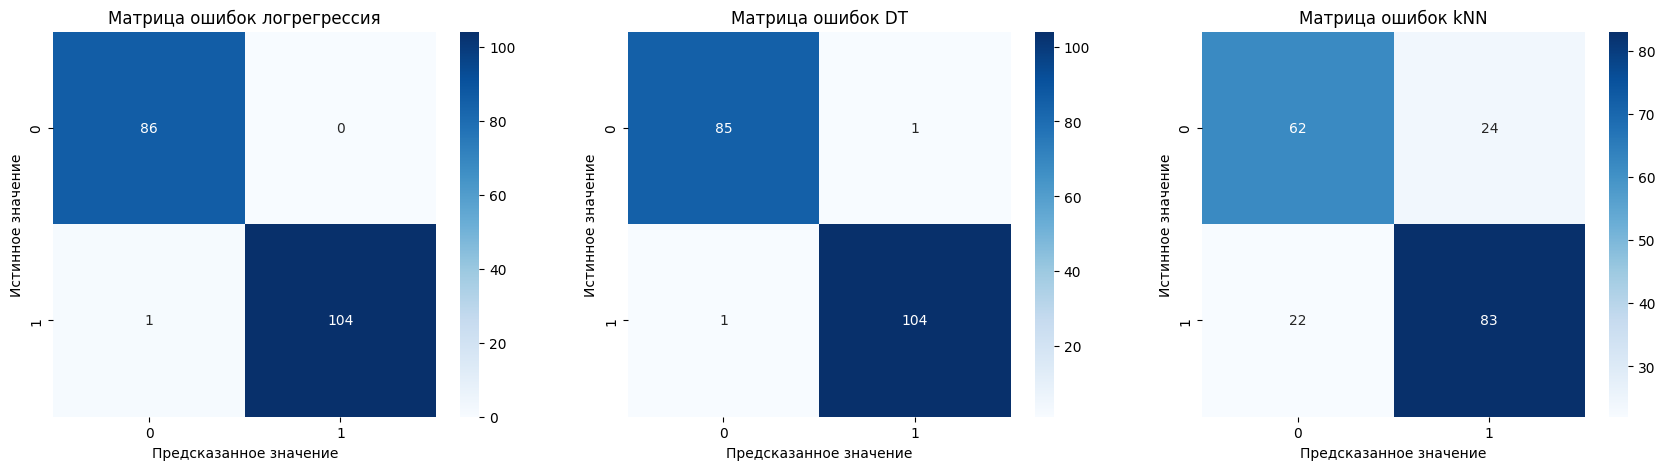

In [195]:
#Строим матрицу ошибок для модели
confus_matrix = metrics.confusion_matrix(y_test, pred_logreg)
confus_matrix1 = metrics.confusion_matrix(y_test, pred_dt)
confus_matrix2 = metrics.confusion_matrix(y_test, pred_knn)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
sns.heatmap(confus_matrix, annot=True, fmt='', cmap='Blues', ax=axes[0])
axes[0].set_title('Матрица ошибок логрегрессия')
axes[0].set_xlabel('Предсказанное значение')
axes[0].set_ylabel('Истинное значение')

sns.heatmap(confus_matrix1, annot=True, fmt='', cmap='Blues', ax=axes[1])
axes[1].set_title('Матрица ошибок DT')
axes[1].set_xlabel('Предсказанное значение')
axes[1].set_ylabel('Истинное значение')

sns.heatmap(confus_matrix2, annot=True, fmt='', cmap='Blues', ax=axes[2])
axes[2].set_title('Матрица ошибок kNN')
axes[2].set_xlabel('Предсказанное значение')
axes[2].set_ylabel('Истинное значение');

* Сравним не только ROC AUC и PR AUC, но и ROC- и PR-кривые. Для их визуализации будем использовать функцию, приведенную ниже:

In [196]:
def plot_roc_pr_curves(true_labels, algorithms):
    """Отрисовка ROC- и PR-кривых.
    Аргументы функции:
    true_labels: истинные метки классов
    algorithms: словарь формата {название_алгоритма: вероятности_принадлежности_к_каждому_классу}
    """
    fig, ax = plt.subplots(1, 2, figsize=(20, 8))
    ax[0].set_title("ROC-кривая", fontsize=20)
    ax[1].set_title("PR-кривая", fontsize=20)

    for alg_name, probabilities in algorithms.items():
        fpr, tpr, _ = roc_curve(true_labels, probabilities[:, 1])
        precisions, recalls, _ = precision_recall_curve(true_labels, probabilities[:, 1])

        ax[0].plot(
            fpr,
            tpr,
            label="{} (ROC AUC = {})".format(
                alg_name,
                round(
                    roc_auc_score(true_labels, probabilities[:, 1]),
                    3
                )
            )
        )
        ax[1].plot(
            recalls,
            precisions,
            label="{} (PR AUC = {})".format(
                alg_name,
                round(
                    average_precision_score(true_labels, probabilities[:, 1]),
                    3
                )
            )
        )

    ax[0].legend(fontsize=14)
    ax[0].set_xlabel("Ложноположительные", fontsize=16)
    ax[0].set_ylabel("Истинно положительные", fontsize=16)

    ax[1].legend(fontsize=14)
    ax[1].set_xlabel("Recall", fontsize=16)
    ax[1].set_ylabel("Precision", fontsize=16)
    plt.show()

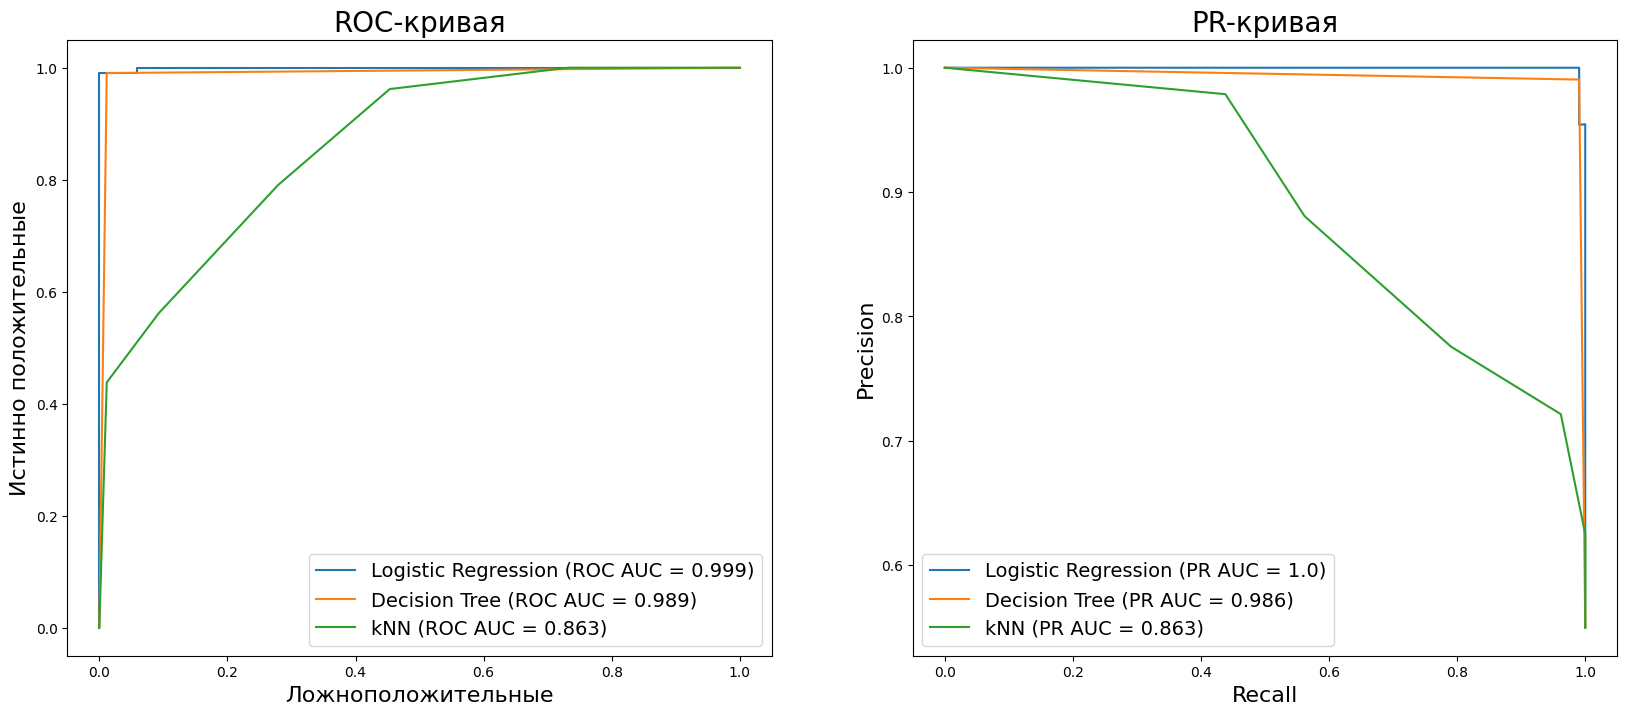

In [197]:
plot_roc_pr_curves(
    y_test,
    {
        "Logistic Regression": proba_logreg,
        "Decision Tree": proba_dt,
        "kNN": proba_knn,
    }
)

* Сагрегируем все метрики моделей

In [198]:
ans_df = pd.DataFrame(
    [all_metrics_logreg, all_metrics_dt, all_metrics_knn],
    index=["Logistic Regression", "Decision Tree", "kNN"]
)
ans_df

,Accuracy,Balanced accuracy,Precision,Recall,F1_score,ROC AUC,PR AUC,Specificity
Logistic Regression,0.994764,0.995238,1.000000,0.990476,0.995215,0.999446,0.995712,1.0000
Decision Tree,0.989529,0.989424,0.990476,0.990476,0.990476,0.989424,0.986279,0.9884
kNN,0.759162,0.755703,0.775701,0.790476,0.783019,0.863068,0.728356,0.7209


* Для каждой метрики выведем список моделей по убыванию их качества

In [199]:
for metric in ans_df.columns:
    sorted_ans_df = ans_df.sort_values(by=metric, ascending=False)
    print(
        "{}:{}{}".format(
            metric,
            " " * (20 - len(metric)),
            sorted_ans_df.index.tolist()
        )
    )

Accuracy:            ['Logistic Regression', 'Decision Tree', 'kNN']
Balanced accuracy:   ['Logistic Regression', 'Decision Tree', 'kNN']
Precision:           ['Logistic Regression', 'Decision Tree', 'kNN']
Recall:              ['Logistic Regression', 'Decision Tree', 'kNN']
F1_score:            ['Logistic Regression', 'Decision Tree', 'kNN']
ROC AUC:             ['Logistic Regression', 'Decision Tree', 'kNN']
PR AUC:              ['Logistic Regression', 'Decision Tree', 'kNN']
Specificity:         ['Logistic Regression', 'Decision Tree', 'kNN']


Согласно всем метрикам наилучшим алгоритмом оказалась логистическая регрессия.

### Подбор гиперпараметров с последующей оценкой

In [200]:
# 1. БАЗОВАЯ МОДЕЛЬ (до оптимизации)

raw_table_data = heart_new
X = raw_table_data.drop(['ССЗ'], axis=1)
y = raw_table_data['ССЗ'].values
raw_table_data_columns = X.columns
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Отбор признаков: SelectKBest с f_classif, k = 10 (можно подобрать, но для примера — 10)
selector = SelectKBest(score_func=f_classif, k=10)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)
model = LogisticRegression(C=0.0001, penalty='l2',solver='liblinear',class_weight=None,random_state=42, max_iter=1000)
model.fit(X_train_selected, y_train)


y_pred_base = model.predict(X_test_selected)
y_proba_base = model.predict_proba(X_test_selected)
print("\n--- Метрики ДО оптимизации ---")
metrics_before = get_all_metrics(y_test, y_pred_base, y_proba_base, print_metrics=True, average='binary')



--- Метрики ДО оптимизации ---
Accuracy = 0.9791
Balanced_accuracy = 0.9810
Precision = 1.0000
Recall = 0.9619
F1_score = 0.9806
ROC AUC = 0.9959
PR AUC = 0.9828
Specificity = 1.0000


In [201]:

# 2. ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ
param_grid = {'C': [0.005, 0.001, 0.1, 0.5, 1, 5, 10, 50, 100],'penalty': ['l1', 'l2'],
             'solver': ['liblinear', 'saga']}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(LogisticRegression(random_state=42, max_iter=2000),param_grid, scoring='f1', cv=cv, n_jobs=-1)
grid_search.fit(X_train_selected, y_train)


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(max_iter=2000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.005, 0.001, 0.1, 0.5, 1, 5, 10, 50, 100],
                         'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='f1')

In [202]:


# 3. МЕТРИКИ ПОСЛЕ ОПТИМИЗАЦИИ
print("\n--- Метрики ПОСЛЕ оптимизации ---")
best_model = grid_search.best_estimator_
y_pred_opt = best_model.predict(X_test_selected)
y_proba_opt = best_model.predict_proba(X_test_selected)

metrics_after = get_all_metrics(y_test, y_pred_opt, y_proba_opt,
                print_metrics=True)


# 4. СРАВНЕНИЕ (опционально красиво)
print("\n" + "="*50)
print("СРАВНЕНИЕ МЕТРИК: ДО → ПОСЛЕ")
print("="*50)
for metric in metrics_before:
    before = metrics_before[metric]
    after = metrics_after[metric]
    sign = "↑" if after > before else "↓" if after < before else "="
    print(f"{metric:<20}: {before:.4f} → {after:.4f} {sign}")


--- Метрики ПОСЛЕ оптимизации ---
Accuracy = 0.9895
Balanced_accuracy = 0.9905
Precision = 1.0000
Recall = 0.9810
F1_score = 0.9904
ROC AUC = 0.9965
PR AUC = 0.9914
Specificity = 1.0000

СРАВНЕНИЕ МЕТРИК: ДО → ПОСЛЕ
Accuracy            : 0.9791 → 0.9895 ↑
Balanced accuracy   : 0.9810 → 0.9905 ↑
Precision           : 1.0000 → 1.0000 =
Recall              : 0.9619 → 0.9810 ↑
F1_score            : 0.9806 → 0.9904 ↑
ROC AUC             : 0.9959 → 0.9965 ↑
PR AUC              : 0.9828 → 0.9914 ↑
Specificity         : 1.0000 → 1.0000 =


## Вклад признаков в предсказание

* Метод, который упорядочивает и визуализирует коэффициенты регрессии для каждого признака

In [203]:
def plot_imp(ssz, importance):
    order = np.argsort(importance)
    ssz = ssz[order]
    importance = importance[order]

    for idx, val in enumerate(importance):
        print(f'{ssz[idx]:40} {val:.4f}')
    plt.figure(figsize=(4, np.ceil(len(ssz) / 4)))

    plt.barh(ssz, importance)
    plt.show()

Модель **LogisticRegression** является линейной и использует весовые коэффициенты для определения важности признаков.

Коэффициенты модели (**Coefficients**):
Для линейных моделей такие как логистическая регрессия, важность признаков можно определить исходя из абсолютных значений коэффициентов. Коэффициенты показывают, насколько сильно каждый признак влияет на предсказание.

Для **дерева решений** важность признаков вычисляется на основе того, насколько каждый признак уменьшает неопределенность в узлах дерева.

Встроенная важность признаков:
В моделях на основе дерева решений, таких как DecisionTreeClassifier, библиотека scikit-learn предоставляет встроенный метод **feature_importances_**, который возвращает значения важности для каждого признака.

Для обеих моделей, можно также применить вышеупомянутые методы, такие как:

**Permutation Importance** (Переменная важность): метод случайной перестановки значений признаков и измерения снижения метрик модели.
Удаление признаков (**Feature Removal**): поочерёдное удаление каждого признака и измерение изменения производительности модели.

In [204]:
heart_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 953 entries, 0 to 954
Data columns (total 36 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Бронхиальная астма                      953 non-null    int64  
 1   Возраст алког                           953 non-null    float64
 2   Работа                                  953 non-null    int64  
 3   Статус Курения                          953 non-null    float64
 4   Переломы                                953 non-null    int64  
 5   Время пробуждения                       953 non-null    int64  
 6   ЛПВП                                    953 non-null    float64
 7   Выход на пенсию                         953 non-null    int64  
 8   Холестерин                              953 non-null    float64
 9   Артериальная гипертония                 953 non-null    int64  
 10  Триглицериды                            953 non-null    float64
 11

Образование                              -1.3483
ЛПВП                                     -1.1813
Работа                                   -0.8464
Время засыпания                          -0.7354
Гепатит                                  -0.6336
Сон после обеда                          -0.4790
Прекращение работы по болезни            -0.3510
Переломы                                 -0.1036
Продолжительность сна                    -0.0522
Возраст алког                            -0.0261
Статус Курения                           -0.0169
Алкоголь                                 -0.0013
Семья                                    -0.0012
Национальность                           -0.0008
Религия                                  -0.0006
Профессия                                -0.0004
Онкология                                0.0011
Частота пасс кур                         0.0160
Абдоминальное ожирение, см               0.0646
Время пробуждения                        0.0794
Травмы за год           

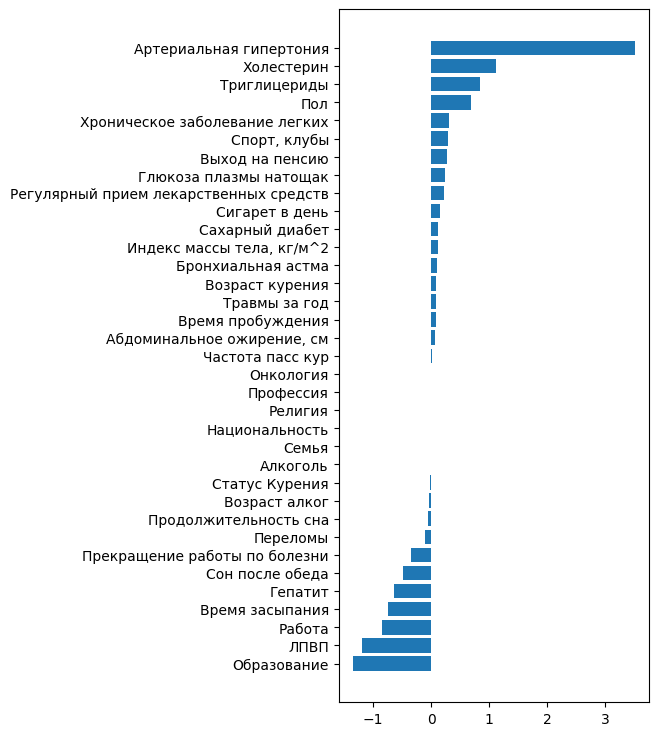

In [208]:
ssz = X.columns
plot_imp(ssz, importance_logreg)

* Выведем абсолютный вклад признаков в предсказание

Профессия                                0.0004
Религия                                  0.0006
Национальность                           0.0008
Онкология                                0.0011
Семья                                    0.0012
Алкоголь                                 0.0013
Частота пасс кур                         0.0160
Статус Курения                           0.0169
Возраст алког                            0.0261
Продолжительность сна                    0.0522
Абдоминальное ожирение, см               0.0646
Время пробуждения                        0.0794
Травмы за год                            0.0884
Возраст курения                          0.0936
Бронхиальная астма                       0.1026
Переломы                                 0.1036
Индекс массы тела, кг/м^2                0.1150
Сахарный диабет                          0.1212
Сигарет в день                           0.1533
Регулярный прием лекарственных средств   0.2167
Глюкоза плазмы натощак                  

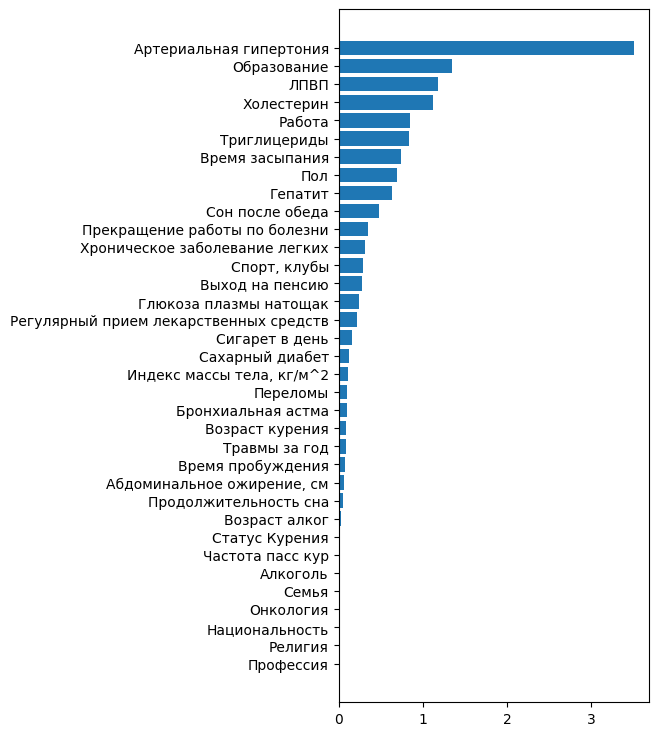

In [210]:
plot_imp(ssz, np.abs(importance_logreg))

Важность признаков, полученная с помощью Деревьев решений

Бронхиальная астма                       0.0000
Возраст алког                            0.0000
Работа                                   0.0000
Статус Курения                           0.0000
Переломы                                 0.0000
Время пробуждения                        0.0000
ЛПВП                                     0.0000
Выход на пенсию                          0.0000
Гепатит                                  0.0000
Триглицериды                             0.0000
Пол                                      0.0000
Сахарный диабет                          0.0000
Спорт, клубы                             0.0000
Семья                                    0.0000
Онкология                                0.0000
Частота пасс кур                         0.0000
Прекращение работы по болезни            0.0000
Время засыпания                          0.0000
Травмы за год                            0.0000
Регулярный прием лекарственных средств   0.0000
Алкоголь                                

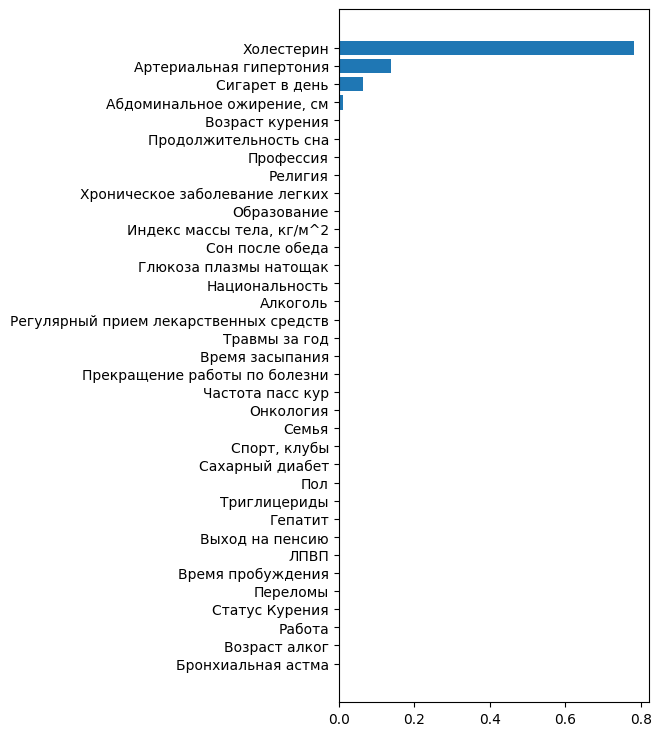

In [211]:
plot_imp(ssz, importance_dt)

# Результат

In [212]:
print("Using the best performing model: Logistic Regression (optimized)")

# Select the first patient from the test set
patient_index = 0
single_patient_data = X_test_selected[patient_index].reshape(1, -1)
single_patient_original = X_test.iloc[[patient_index]]
actual_ssz = y_test[patient_index]

# Make a prediction using the best_model
predicted_ssz = best_model.predict(single_patient_data)[0]
predicted_proba = best_model.predict_proba(single_patient_data)[0]

print("\n--- Selected Patient Details (original features) ---")
display(single_patient_original)

print(f"Actual 'ССЗ' value for this patient: {actual_ssz}")
print(f"Predicted 'ССЗ' value for this patient: {predicted_ssz}")
print(f"Prediction probabilities (class 0, class 1): {predicted_proba.round(4)}")

if predicted_ssz == 1:
    print("\nBased on the model, this patient is predicted to have a cardiovascular disease (ССЗ).")
else:
    print("\nBased on the model, this patient is predicted not to have a cardiovascular disease (ССЗ).")

Using the best performing model: Logistic Regression (optimized)

--- Selected Patient Details (original features) ---


,Бронхиальная астма,Возраст алког,Работа,Статус Курения,Переломы,Время пробуждения,ЛПВП,Выход на пенсию,Холестерин,Артериальная гипертония,...,Сон после обеда,Время засыпания,Хроническое заболевание легких,Сигарет в день,Образование,"Индекс массы тела, кг/м^2",Прекращение работы по болезни,Религия,Профессия,Продолжительность сна
280,0,15.0,0,221.034132,1,4,-0.38,0,4.9,1,...,0,11,1,20.0,2,30.7,1,41.09383,137.052145,-6


Actual 'ССЗ' value for this patient: 1
Predicted 'ССЗ' value for this patient: 1
Prediction probabilities (class 0, class 1): [0.0016 0.9984]

Based on the model, this patient is predicted to have a cardiovascular disease (ССЗ).
